# 📊 Explainability-First Financial Modeling — EDA · ML · DL · Transformer
### Enhanced Portfolio Dataset | Polyglot Finance AI Roadmap
> Built on: `pandas`, `numpy`, `scipy`, `statsmodels`, `sklearn`, `xgboost`, `lightgbm`, `torch`, `transformers`, `ta`, `mplfinance`, `plotly`, `seaborn`, `matplotlib`


## 🔧 0. Install & Import Libraries

In [1]:
# ─── Install all required libraries ───────────────────────────────────────────
!pip install -q pandas numpy scipy statsmodels scikit-learn xgboost lightgbm \
    torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install -q transformers datasets tokenizers
!pip install -q ta mplfinance plotly seaborn matplotlib openpyxl
!pip install -q arch pmdarima tsfresh shap empyrical pyfolio-reloaded
!pip install -q umap-learn kneed tensorboard
print("✅ All libraries installed")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
✅ All libraries installed


In [2]:
# ─── Core Imports ─────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')

# Numerical & Data
import numpy as np
import pandas as pd
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import mplfinance as mpf

# Technical Analysis
import ta
from ta.trend import MACD, SMAIndicator, EMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

# Machine Learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Transformer / NLP
from transformers import pipeline as hf_pipeline

# Finance-specific
import shap
try:
    import empyrical
    HAS_EMPYRICAL = True
except: HAS_EMPYRICAL = False

import os, math, json
from datetime import datetime

# ─── Aesthetics ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'text.color': '#e6edf3',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'axes.labelcolor': '#e6edf3', 'grid.color': '#21262d',
    'figure.dpi': 120, 'savefig.dpi': 150,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'monospace'
})
PALETTE = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657',
           '#79c0ff','#56d364','#ff7b72','#bc8cff','#e3b341']
print("✅ All imports successful | PyTorch:", torch.__version__)


✅ All imports successful | PyTorch: 2.10.0+cu128


## 📂 1. Data Loading & Overview

In [3]:
# ─── Upload the XLSX file ─────────────────────────────────────────────────────
from google.colab import files
print("📁 Please upload: Enhanced_Portfolio_AllAlgorithms_20260114_170149__2_.xlsx")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
print(f"✅ Uploaded: {fname}")


📁 Please upload: Enhanced_Portfolio_AllAlgorithms_20260114_170149__2_.xlsx


Saving Enhanced_Portfolio_AllAlgorithms_20260114_170149 (2).xlsx to Enhanced_Portfolio_AllAlgorithms_20260114_170149 (2).xlsx
✅ Uploaded: Enhanced_Portfolio_AllAlgorithms_20260114_170149 (2).xlsx


In [4]:
# ─── Load all sheets ──────────────────────────────────────────────────────────
xl = pd.ExcelFile(fname)
print("📋 Available Sheets:", xl.sheet_names)

df       = pd.read_excel(xl, sheet_name='Enhanced_Daily_Per_Symbol', parse_dates=['Date'])
df_sum   = pd.read_excel(xl, sheet_name='Enhanced_Summary')
df_back  = pd.read_excel(xl, sheet_name='Enhanced_Backtests')
df_eq    = pd.read_excel(xl, sheet_name='Portfolio_Equity', parse_dates=['Date'] if 'Date' in pd.read_excel(xl,'Portfolio_Equity',nrows=0).columns else None)
df_met   = pd.read_excel(xl, sheet_name='Portfolio_Metrics')
df_fund  = pd.read_excel(xl, sheet_name='Fundamentals')
df_comp  = pd.read_excel(xl, sheet_name='Novel_Algorithms_Comparison')

# Sort
df.sort_values(['Symbol','Date'], inplace=True)
df.reset_index(drop=True, inplace=True)

SYMBOLS = df['Symbol'].unique().tolist()
print(f"\n🏦 Symbols ({len(SYMBOLS)}): {SYMBOLS}")
print(f"📅 Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"📐 Shape: {df.shape} | Columns: {df.shape[1]}")
print(f"\n{df.describe().round(3).T[['mean','std','min','max']].head(15)}")


📋 Available Sheets: ['Enhanced_Daily_Per_Symbol', 'TS_NVDA', 'TS_MSFT', 'TS_AAPL', 'TS_AMZN', 'TS_GOOGL', 'TS_META', 'TS_AVGO', 'TS_TSLA', 'TS_LLY', 'TS_JPM', 'Enhanced_Summary', 'Enhanced_Backtests', 'Portfolio_Equity', 'Portfolio_Metrics', 'Fundamentals', 'LWPC_Weights', 'ARFS_RobustScores', 'CASP_Leadership', 'Novel_Algorithms_Comparison', 'Novel_Algorithms_Info']

🏦 Symbols (10): ['AAPL', 'AMZN', 'AVGO', 'GOOGL', 'JPM', 'LLY', 'META', 'MSFT', 'NVDA', 'TSLA']
📅 Date range: 2026-01-02 → 2026-01-14
📐 Shape: (90, 95) | Columns: 95

                                  mean          std                  min  \
Date               2026-01-08 10:40:00          NaN  2026-01-02 00:00:00   
Open                           433.308      250.778               183.22   
High                           438.382      254.558               184.45   
Low                            426.487      246.113               180.91   
Close                          431.803      250.101               181.75   
Adj Cl

## 🔍 2. Exploratory Data Analysis (EDA)

### 2.1 Data Quality & Descriptive Statistics

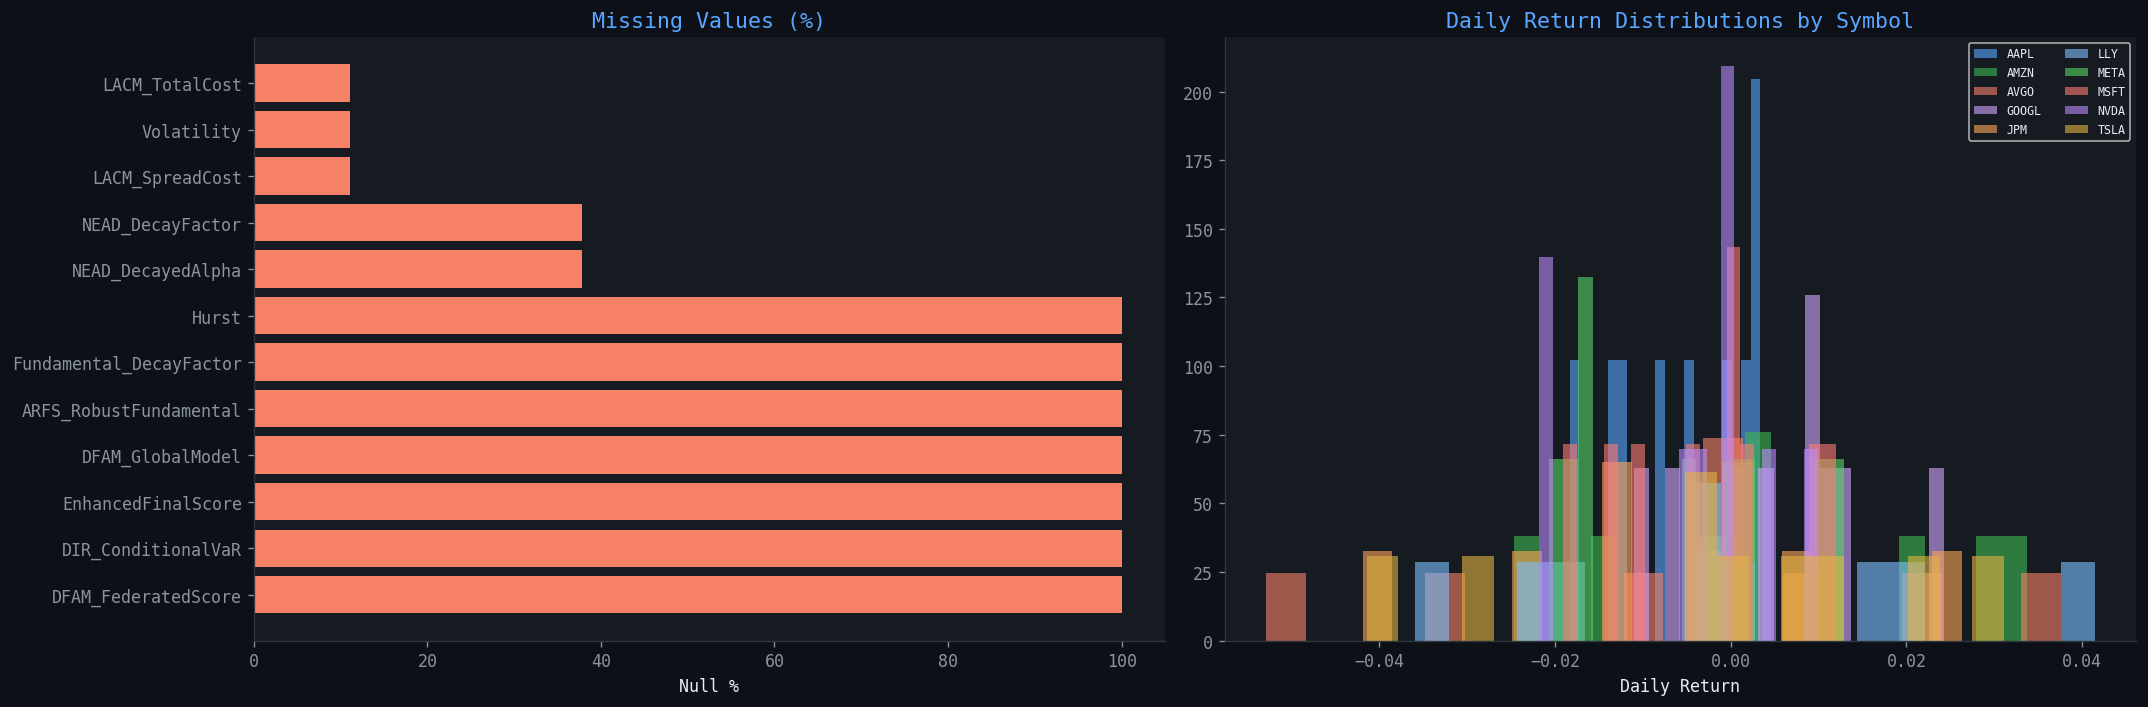


📊 Return Statistics per Symbol:
        Mean_Return  Volatility  Skewness  Kurtosis
Symbol                                             
AAPL       -0.00555     0.00807  -0.30468  -1.36929
AMZN        0.00503     0.01946   0.08173  -1.01467
AVGO       -0.00349     0.02683  -0.40608  -0.33419
GOOGL       0.00595     0.01074  -0.05924  -0.59303
JPM        -0.00650     0.01960  -0.17473  -0.27291
LLY        -0.00040     0.02395   0.26672  -0.74188
META       -0.00558     0.01302   0.18880  -1.51085
MSFT       -0.00262     0.01053  -0.10645  -1.08248
NVDA       -0.00420     0.01085  -0.71999  -0.61785
TSLA       -0.00060     0.02265  -0.50208  -0.55883


In [5]:
# ─── Null heatmap ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

null_pct = df.isnull().mean().sort_values(ascending=False)
top_null = null_pct[null_pct > 0]
if len(top_null) > 0:
    axes[0].barh(top_null.index, top_null.values * 100, color='#f78166')
    axes[0].set_xlabel('Null %'); axes[0].set_title('Missing Values (%)', fontsize=13, color='#58a6ff')
else:
    axes[0].text(0.5, 0.5, '✅ No Missing Values', ha='center', va='center',
                 fontsize=15, color='#3fb950', transform=axes[0].transAxes)
    axes[0].set_title('Missing Values', fontsize=13, color='#58a6ff')

# Distribution of Daily Returns per symbol
for i, sym in enumerate(SYMBOLS):
    d = df[df.Symbol == sym]['Daily_Return'].dropna()
    axes[1].hist(d, bins=20, alpha=0.6, label=sym, color=PALETTE[i], density=True)
axes[1].set_title('Daily Return Distributions by Symbol', fontsize=13, color='#58a6ff')
axes[1].set_xlabel('Daily Return')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

# Stats table
stats_df = df.groupby('Symbol')['Daily_Return'].agg(['mean','std',
    lambda x: stats.skew(x.dropna()), lambda x: stats.kurtosis(x.dropna())])
stats_df.columns = ['Mean_Return','Volatility','Skewness','Kurtosis']
stats_df = stats_df.round(5)
print("\n📊 Return Statistics per Symbol:")
print(stats_df.to_string())


### 2.2 Price & Volume Analysis

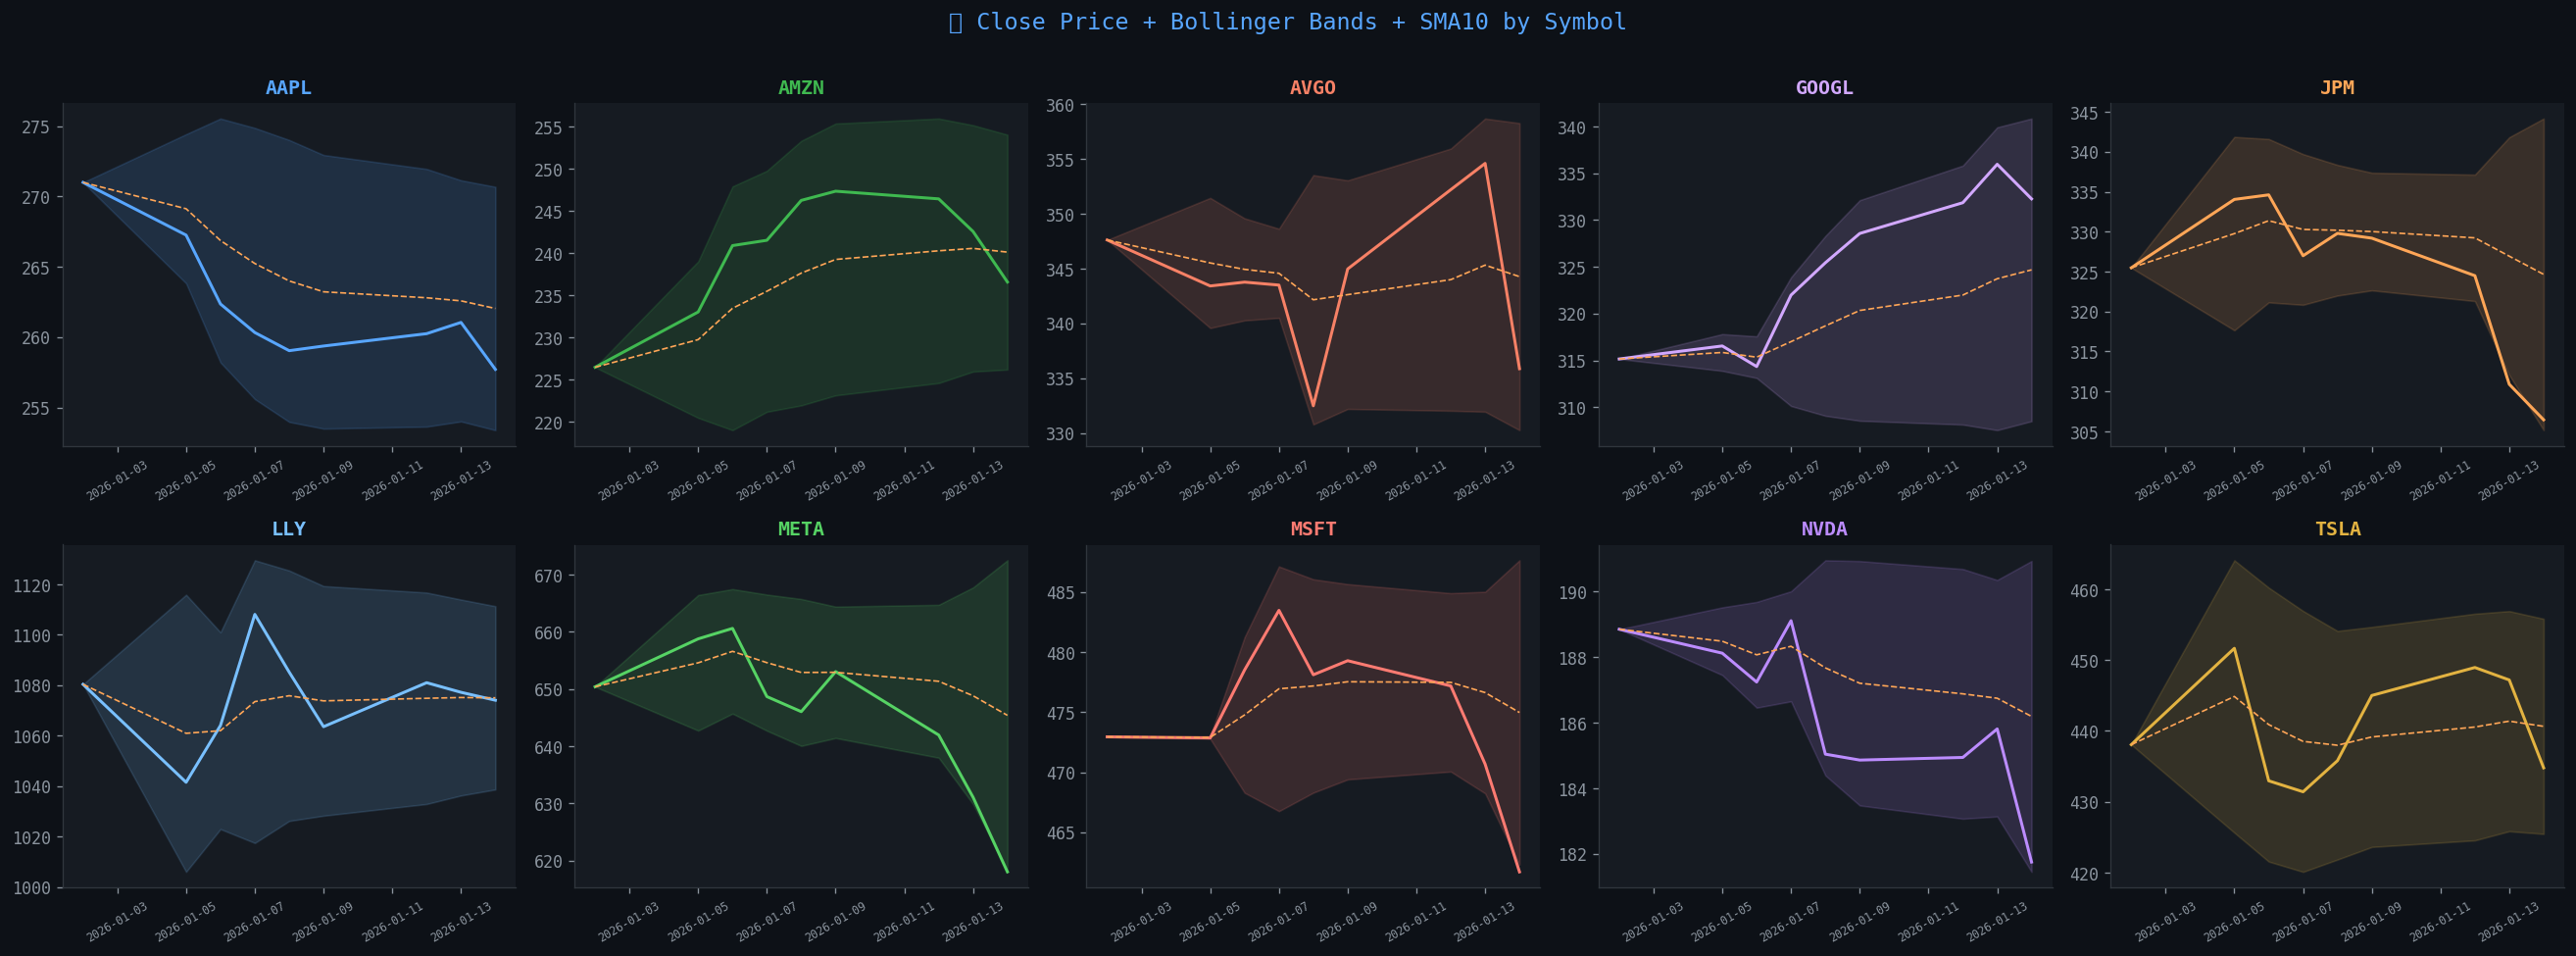

In [6]:
# ─── Close prices all symbols ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for i, sym in enumerate(SYMBOLS):
    d = df[df.Symbol == sym].set_index('Date')
    axes[i].plot(d.index, d['Close'], color=PALETTE[i], lw=1.8, label='Close')
    axes[i].plot(d.index, d['SMA_10'], color='#ffa657', lw=1, ls='--', label='SMA10')
    axes[i].fill_between(d.index, d['BB_Lower'], d['BB_Upper'], alpha=0.15, color=PALETTE[i])
    axes[i].set_title(sym, fontsize=12, color=PALETTE[i], fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)
plt.suptitle('📈 Close Price + Bollinger Bands + SMA10 by Symbol', fontsize=14,
             color='#58a6ff', y=1.01)
plt.tight_layout(); plt.show()


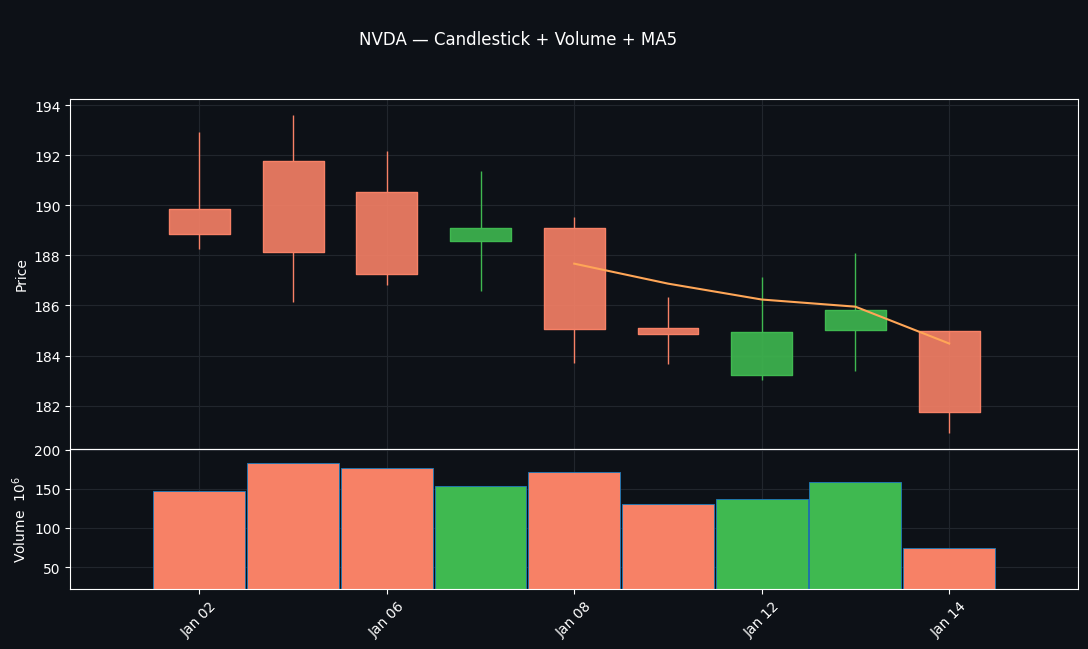

In [7]:
# ─── Candlestick (mplfinance) for NVDA ────────────────────────────────────────
nvda = df[df.Symbol=='NVDA'].set_index('Date')[['Open','High','Low','Close','Volume']].copy()
nvda.index = pd.DatetimeIndex(nvda.index)

mc = mpf.make_marketcolors(up='#3fb950', down='#f78166', edge='inherit',
                            wick='inherit', volume={'up':'#3fb950','down':'#f78166'})
s  = mpf.make_mpf_style(marketcolors=mc, base_mpl_style='dark_background',
                         facecolor='#0d1117', figcolor='#0d1117', gridcolor='#21262d')

apds = [mpf.make_addplot(nvda['Close'].rolling(5).mean(), color='#ffa657', width=1.5)]
mpf.plot(nvda, type='candle', style=s, volume=True, addplot=apds,
         title='\nNVDA — Candlestick + Volume + MA5', figsize=(14, 7))
plt.show()


### 2.3 Correlation & Factor Analysis

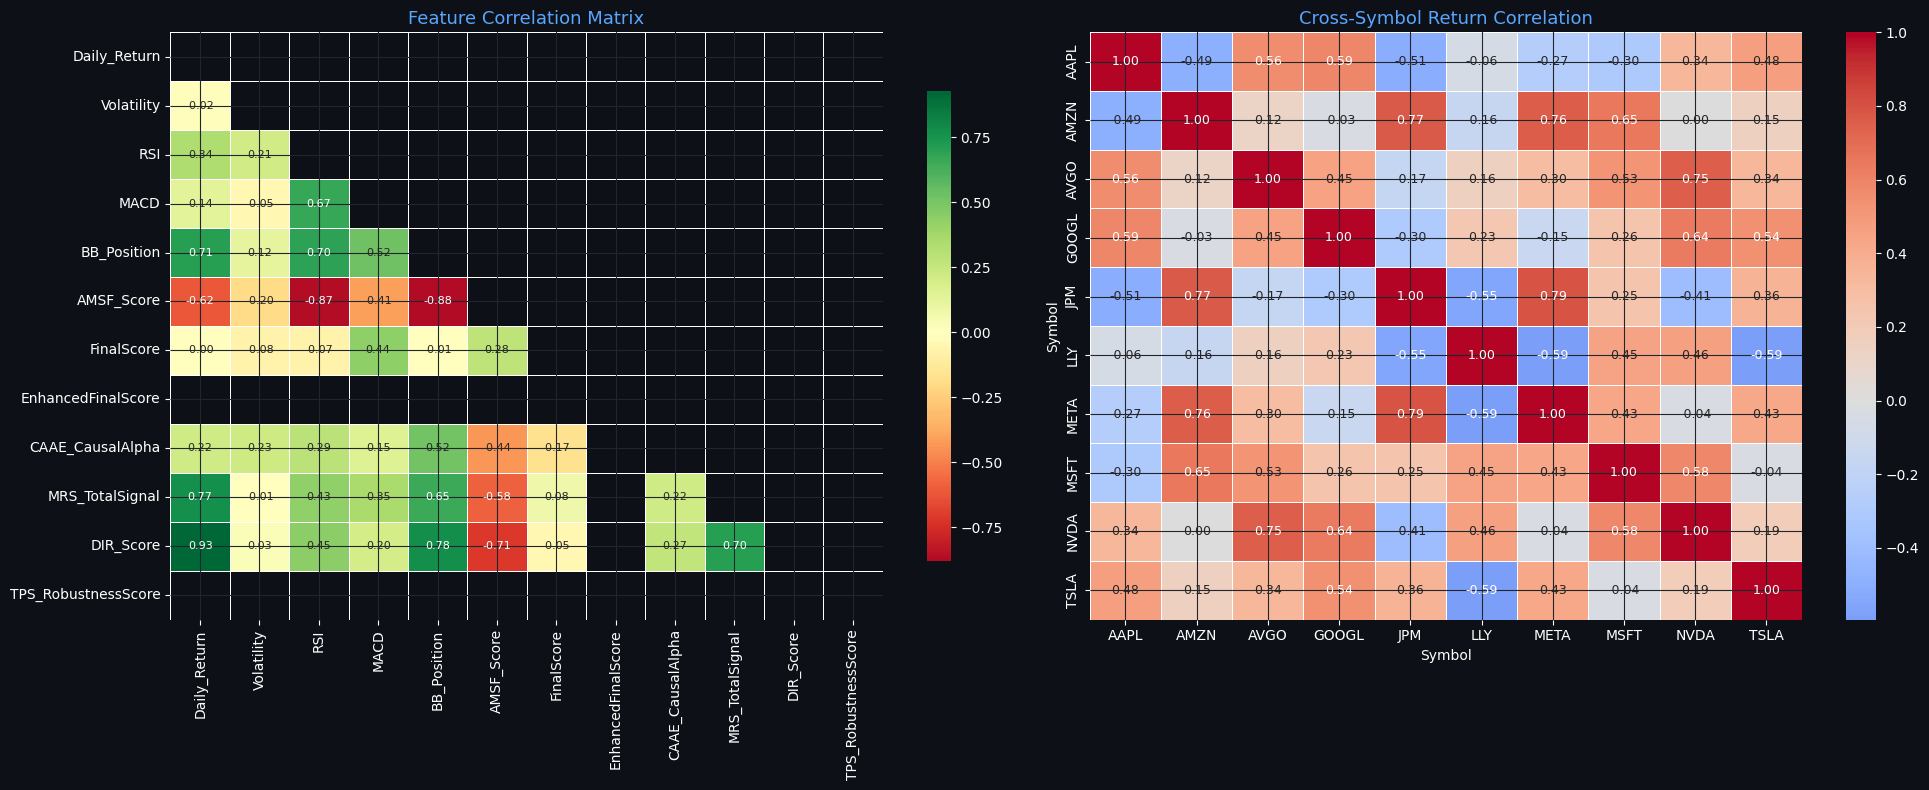

In [8]:
# ─── Correlation heatmap of key features ─────────────────────────────────────
feat_cols = ['Daily_Return','Volatility','RSI','MACD','BB_Position',
             'AMSF_Score','FinalScore','EnhancedFinalScore',
             'CAAE_CausalAlpha','MRS_TotalSignal','DIR_Score','TPS_RobustnessScore']
corr = df[feat_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5, annot_kws={'size':8},
            cbar_kws={'shrink':0.8})
axes[0].set_title('Feature Correlation Matrix', fontsize=13, color='#58a6ff')

# Cross-symbol close price correlation
pivot = df.pivot_table(index='Date', columns='Symbol', values='Close')
sym_corr = pivot.pct_change().corr()
sns.heatmap(sym_corr, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size':9})
axes[1].set_title('Cross-Symbol Return Correlation', fontsize=13, color='#58a6ff')
plt.tight_layout(); plt.show()


### 2.4 Technical Indicators Deep Dive

In [9]:
# ─── Multi-panel technical indicator chart for AAPL ──────────────────────────
sym = 'AAPL'
d = df[df.Symbol==sym].set_index('Date')

fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.04,
                    subplot_titles=('Price + Bollinger Bands','RSI','MACD','Volume'),
                    row_heights=[0.4, 0.2, 0.25, 0.15])

# Price + BB
fig.add_trace(go.Candlestick(x=d.index, open=d.Open, high=d.High,
              low=d.Low, close=d.Close, name='Price',
              increasing_line_color='#3fb950', decreasing_line_color='#f78166'), row=1, col=1)
fig.add_trace(go.Scatter(x=d.index, y=d.BB_Upper, line=dict(color='#58a6ff', dash='dash', width=1), name='BB Upper'), row=1, col=1)
fig.add_trace(go.Scatter(x=d.index, y=d.BB_Lower, line=dict(color='#58a6ff', dash='dash', width=1),
              fill='tonexty', fillcolor='rgba(88,166,255,0.08)', name='BB Lower'), row=1, col=1)
fig.add_trace(go.Scatter(x=d.index, y=d.SMA_50, line=dict(color='#ffa657', width=1.5), name='SMA50'), row=1, col=1)

# RSI
fig.add_trace(go.Scatter(x=d.index, y=d.RSI, line=dict(color='#d2a8ff', width=1.5), name='RSI'), row=2, col=1)
fig.add_hline(y=70, line_dash='dot', line_color='#f78166', row=2, col=1)
fig.add_hline(y=30, line_dash='dot', line_color='#3fb950', row=2, col=1)

# MACD
fig.add_trace(go.Scatter(x=d.index, y=d.MACD, line=dict(color='#3fb950'), name='MACD'), row=3, col=1)
fig.add_trace(go.Scatter(x=d.index, y=d.MACD_Signal, line=dict(color='#f78166'), name='Signal'), row=3, col=1)
fig.add_trace(go.Bar(x=d.index, y=d.MACD_Hist, name='Hist', marker_color='#ffa657'), row=3, col=1)

# Volume
fig.add_trace(go.Bar(x=d.index, y=d.Volume, name='Volume', marker_color='#58a6ff', opacity=0.6), row=4, col=1)

fig.update_layout(title=f'📊 {sym} — Full Technical Dashboard', height=750,
                  paper_bgcolor='#0d1117', plot_bgcolor='#161b22', font_color='#e6edf3',
                  showlegend=True, xaxis_rangeslider_visible=False)
fig.show()


### 2.5 Novel Algorithm Score Analysis

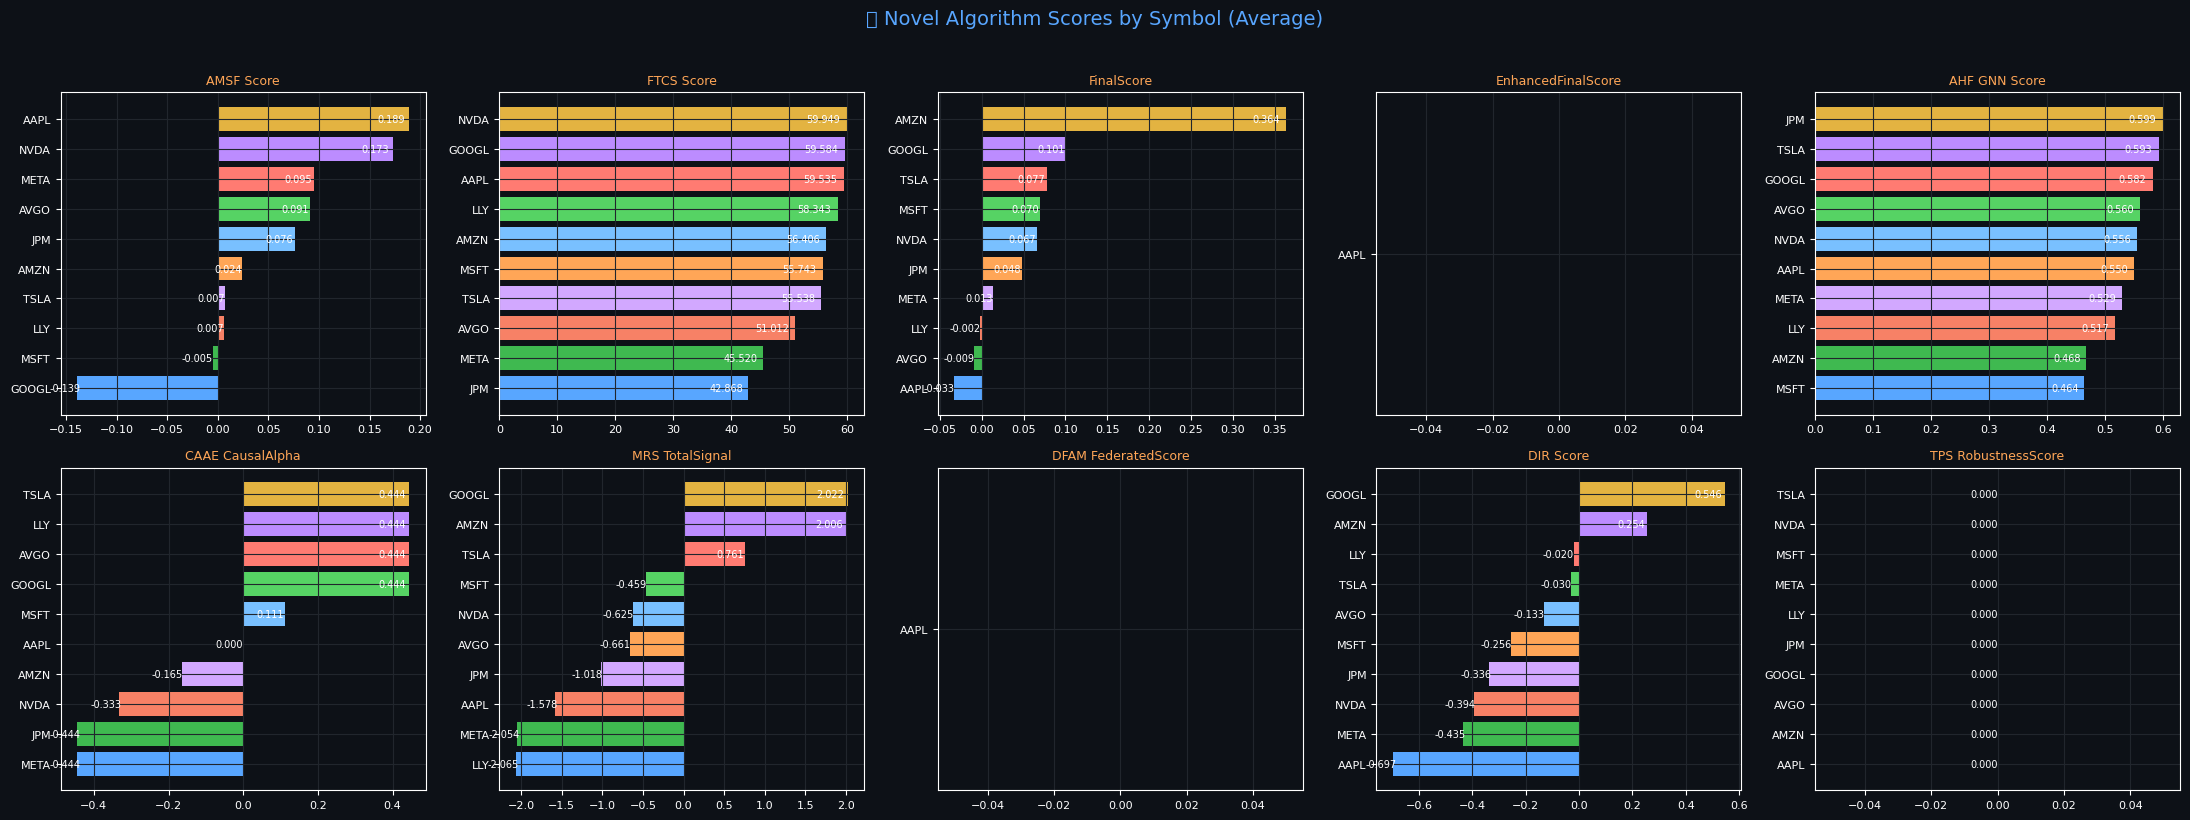

In [10]:
# ─── Novel Algorithm Scores per symbol ───────────────────────────────────────
algo_cols = ['AMSF_Score','FTCS_Score','FinalScore','EnhancedFinalScore',
             'AHF_GNN_Score','CAAE_CausalAlpha','MRS_TotalSignal',
             'DFAM_FederatedScore','DIR_Score','TPS_RobustnessScore']

algo_avg = df.groupby('Symbol')[algo_cols].mean().round(4)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for i, col in enumerate(algo_cols):
    vals = algo_avg[col].sort_values(ascending=True)
    bars = axes[i].barh(vals.index, vals.values, color=PALETTE)
    axes[i].set_title(col.replace('_',' '), fontsize=9, color='#ffa657')
    axes[i].tick_params(labelsize=8)
    for bar, v in zip(bars, vals.values):
        axes[i].text(bar.get_width()*0.98, bar.get_y()+bar.get_height()/2,
                     f'{v:.3f}', va='center', ha='right', fontsize=7, color='white')
plt.suptitle('🧠 Novel Algorithm Scores by Symbol (Average)', fontsize=14, color='#58a6ff', y=1.02)
plt.tight_layout(); plt.show()

# Radar chart via plotly
categories = algo_cols
fig2 = go.Figure()
for i, sym in enumerate(SYMBOLS):
    row = algo_avg.loc[sym]
    vals = (row - row.min()) / (row.max() - row.min() + 1e-9)  # normalize 0-1
    fig2.add_trace(go.Scatterpolar(r=vals.tolist()+[vals.iloc[0]],
                   theta=categories+[categories[0]], fill='toself',
                   name=sym, opacity=0.6,
                   line=dict(color=PALETTE[i])))
fig2.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0,1]),
                   bgcolor='#161b22'),
                   paper_bgcolor='#0d1117', font_color='#e6edf3',
                   title='🕸️ Normalized Algorithm Score Radar', height=500)
fig2.show()


### 2.6 Regime, Clustering & Time-Series Stationarity

📈 Augmented Dickey-Fuller Test (Close Prices):
Symbol       ADF Stat    p-value   Stationary
----------------------------------------------
AAPL          -3.0497     0.0305        ✅ Yes
AMZN           0.1893     0.9717         ❌ No
AVGO          -2.4632     0.1247         ❌ No
GOOGL         -0.8118     0.8156         ❌ No
JPM            0.1779     0.9710         ❌ No
LLY           -5.8228     0.0000        ✅ Yes
META           1.9334     0.9986         ❌ No
MSFT          -0.0375     0.9553         ❌ No
NVDA          -0.8674     0.7985         ❌ No
TSLA          -4.9979     0.0000        ✅ Yes


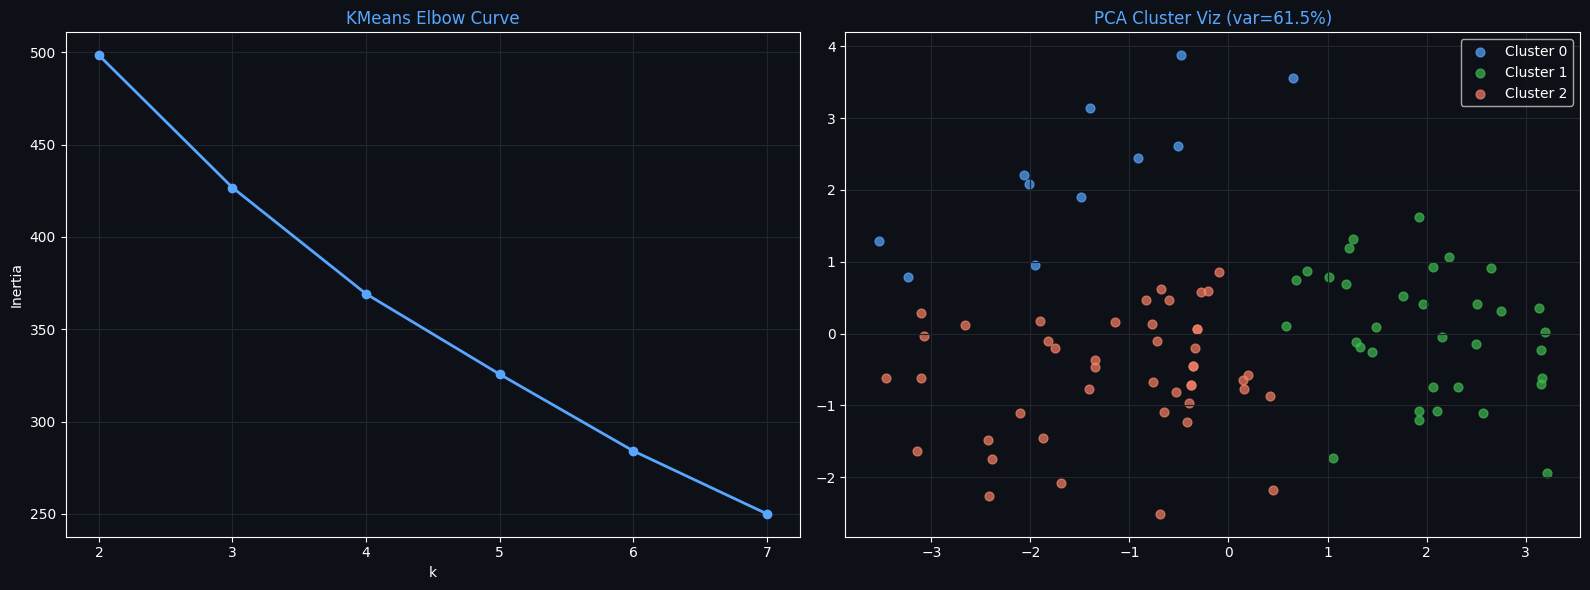

In [11]:
# ─── ADF Stationarity Test ────────────────────────────────────────────────────
print("📈 Augmented Dickey-Fuller Test (Close Prices):")
print(f"{'Symbol':<8} {'ADF Stat':>12} {'p-value':>10} {'Stationary':>12}")
print('-'*46)
for sym in SYMBOLS:
    closes = df[df.Symbol==sym]['Close'].dropna()
    adf_res = adfuller(closes)
    is_stat = '✅ Yes' if adf_res[1] < 0.05 else '❌ No'
    print(f"{sym:<8} {adf_res[0]:>12.4f} {adf_res[1]:>10.4f} {is_stat:>12}")

# ─── KMeans Clustering on feature space ──────────────────────────────────────
cluster_feats = ['Daily_Return','Volatility','RSI','MACD','AMSF_Score',
                 'FinalScore','CAAE_CausalAlpha','DIR_Score']
X_cl = df[cluster_feats].fillna(df[cluster_feats].mean())
scaler_cl = StandardScaler()
X_sc = scaler_cl.fit_transform(X_cl)

# Elbow
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_sc).inertia_
            for k in range(2, 8)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(range(2, 8), inertias, 'o-', color='#58a6ff', lw=2)
axes[0].set_title('KMeans Elbow Curve', fontsize=12, color='#58a6ff')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_sc)
df['Cluster'] = km.labels_

# PCA for 2D viz
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(X_sc)
for c in [0, 1, 2]:
    mask = df['Cluster'] == c
    axes[1].scatter(Xp[mask, 0], Xp[mask, 1], c=PALETTE[c], alpha=0.7,
                    label=f'Cluster {c}', s=40)
axes[1].set_title(f'PCA Cluster Viz (var={pca.explained_variance_ratio_.sum():.1%})',
                  fontsize=12, color='#58a6ff')
axes[1].legend()
plt.tight_layout(); plt.show()


### 2.7 Fundamentals & Portfolio Metrics

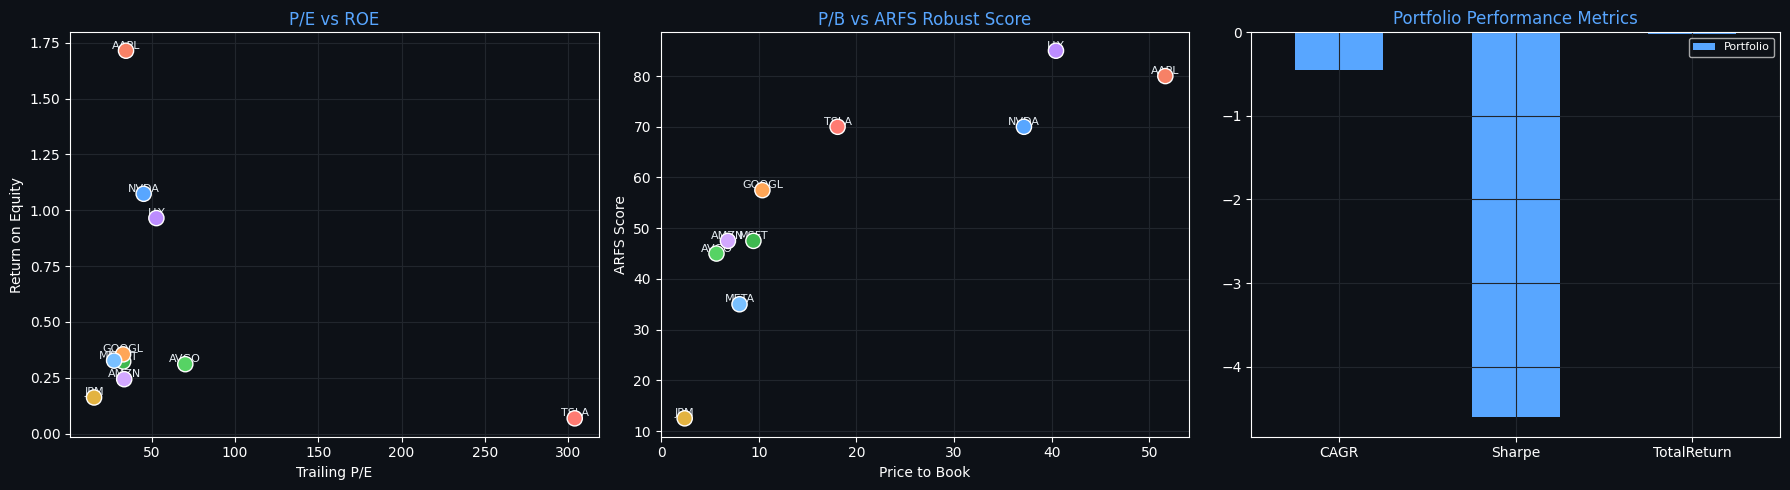

In [12]:
# ─── Fundamentals scatter ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_fund['trailingPE'], df_fund['returnOnEquity'],
                c=PALETTE[:len(df_fund)], s=120, edgecolors='white', zorder=5)
for _, row in df_fund.iterrows():
    axes[0].annotate(row['Symbol'], (row['trailingPE'], row['returnOnEquity']),
                     fontsize=8, color='#e6edf3', ha='center', va='bottom')
axes[0].set_xlabel('Trailing P/E'); axes[0].set_ylabel('Return on Equity')
axes[0].set_title('P/E vs ROE', fontsize=12, color='#58a6ff')

axes[1].scatter(df_fund['priceToBook'], df_fund['ARFS_RobustFundamental'],
                c=PALETTE[:len(df_fund)], s=120, edgecolors='white', zorder=5)
for _, row in df_fund.iterrows():
    axes[1].annotate(row['Symbol'], (row['priceToBook'], row['ARFS_RobustFundamental']),
                     fontsize=8, color='#e6edf3', ha='center', va='bottom')
axes[1].set_xlabel('Price to Book'); axes[1].set_ylabel('ARFS Score')
axes[1].set_title('P/B vs ARFS Robust Score', fontsize=12, color='#58a6ff')

# Portfolio metrics bar
metrics = df_met.set_index('Name')
metrics[['CAGR','Sharpe','TotalReturn']].T.plot(kind='bar', ax=axes[2],
    color=PALETTE[:len(metrics)], rot=0)
axes[2].set_title('Portfolio Performance Metrics', fontsize=12, color='#58a6ff')
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 🤖 3. Machine Learning Models

### 3.1 Feature Engineering

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────
# Target
# ─────────────────────────────────────────
TARGET = 'Daily_Return'

# ─────────────────────────────────────────
# Feature list (target removed)
# ─────────────────────────────────────────
ml_feats = [
    'Open','High','Low','Close','Volume','Volatility',
    'SMA_10','SMA_50','EMA_12','EMA_26','RSI','MACD','MACD_Hist',
    'BB_Position','AMSF_Score','FTCS_Score','FinalScore','EnhancedFinalScore',
    'CAAE_CausalAlpha','MRS_TotalSignal','DIR_Score','TPS_RobustnessScore',
    'AHF_GNN_Score','DFAM_FederatedScore','LWPC_Weight','ARFS_RobustFundamental',
    'MHRP_ReturnForecast','Hurst','DPS_PositionSize','Drawdown'
]

# ─────────────────────────────────────────
# Build ML dataframe
# ─────────────────────────────────────────
df_ml = df[['Date','Symbol'] + ml_feats + [TARGET]].copy()

# Remove duplicate columns
df_ml = df_ml.loc[:, ~df_ml.columns.duplicated()]

# Sort properly for time-series
df_ml = df_ml.sort_values(['Symbol','Date']).reset_index(drop=True)

# ─────────────────────────────────────────
# Lag features
# ─────────────────────────────────────────
for lag in [1,2,3]:
    df_ml[f'Return_lag{lag}'] = df_ml.groupby('Symbol')[TARGET].shift(lag)
    df_ml[f'Score_lag{lag}']  = df_ml.groupby('Symbol')['FinalScore'].shift(lag)

# ─────────────────────────────────────────
# Rolling statistics
# ─────────────────────────────────────────
df_ml['Roll3_Return'] = df_ml.groupby('Symbol')[TARGET].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

df_ml['Roll3_Vol'] = df_ml.groupby('Symbol')['Volatility'].transform(
    lambda x: x.rolling(3, min_periods=1).std()
)

# ─────────────────────────────────────────
# Fill missing values safely
# ─────────────────────────────────────────
df_ml = df_ml.fillna(method='ffill')
df_ml = df_ml.fillna(method='bfill')

# Drop only rows where TARGET missing
df_ml = df_ml.dropna(subset=[TARGET])

# ─────────────────────────────────────────
# Feature columns
# ─────────────────────────────────────────
feat_cols_ml = [c for c in df_ml.columns if c not in ['Date','Symbol',TARGET]]

# Feature matrix
X = df_ml[feat_cols_ml].values
y = df_ml[TARGET].values

# ─────────────────────────────────────────
# Train/test split
# ─────────────────────────────────────────
split = int(len(X) * 0.8)

X_tr = X[:split]
X_te = X[split:]

y_tr = y[:split]
y_te = y[split:]

# Safety check
if len(X_tr) == 0 or len(X_te) == 0:
    raise ValueError("Dataset empty after preprocessing. Check feature columns or NaN handling.")

# ─────────────────────────────────────────
# Scaling
# ─────────────────────────────────────────
scaler = StandardScaler()

X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# ─────────────────────────────────────────
# Summary
# ─────────────────────────────────────────
print("✅ ML Dataset Built Successfully")
print("Train shape:", X_tr_s.shape)
print("Test shape :", X_te_s.shape)
print("Total features:", len(feat_cols_ml))
print("Total samples:", len(df_ml))

✅ ML Dataset Built Successfully
Train shape: (72, 38)
Test shape : (18, 38)
Total features: 38
Total samples: 90


### 3.2 Linear Models (Ridge, Lasso, ElasticNet)

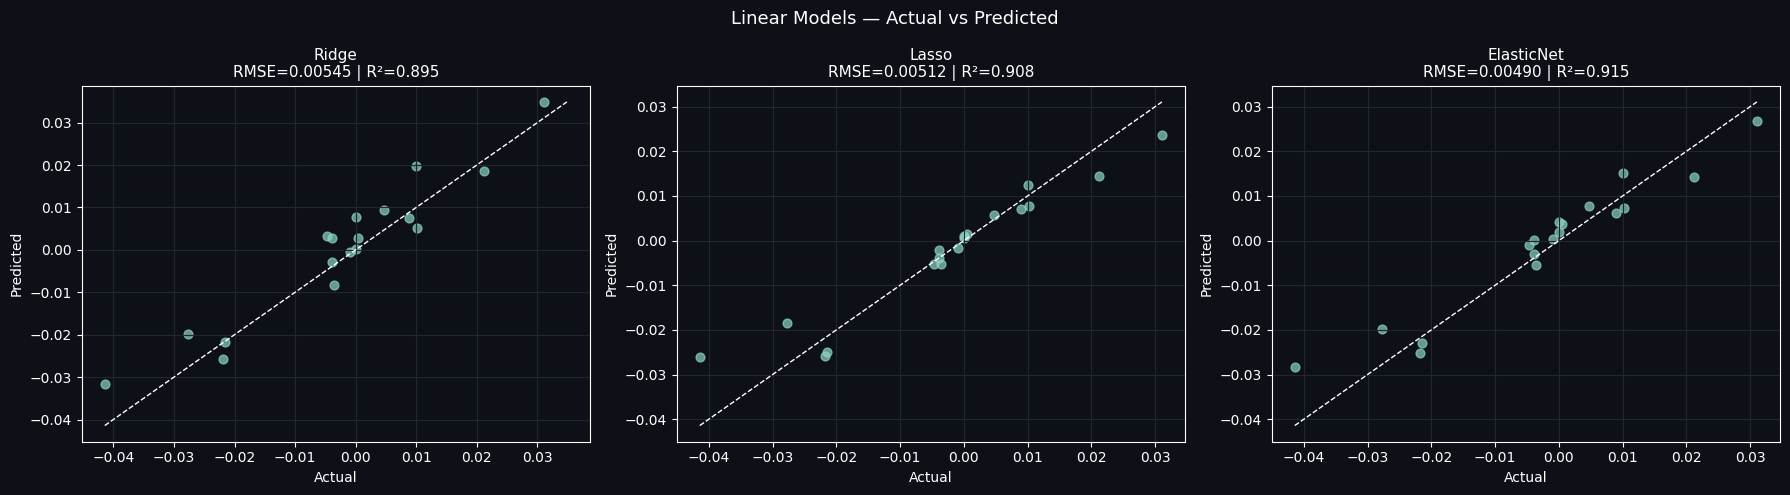

                RMSE        R2
Ridge       0.005453  0.895147
Lasso       0.005120  0.907553
ElasticNet  0.004904  0.915167


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ─── Handle NaN values ──────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')

X_tr_imp = imputer.fit_transform(X_tr)
X_te_imp = imputer.transform(X_te)

# ─── Scale features ─────────────────────────────────────────────────
scaler = StandardScaler()

X_tr_s = scaler.fit_transform(X_tr_imp)
X_te_s = scaler.transform(X_te_imp)

# ─── Regularized Linear Models ──────────────────────────────────────
linear_models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000)
}

results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, mdl) in zip(axes, linear_models.items()):

    mdl.fit(X_tr_s, y_tr)
    pred = mdl.predict(X_te_s)

    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)

    results[name] = {
        'RMSE': rmse,
        'R2': r2,
        'model': mdl,
        'pred': pred
    }

    ax.scatter(y_te, pred, alpha=0.7, s=40)

    mn = min(y_te.min(), pred.min())
    mx = max(y_te.max(), pred.max())

    ax.plot([mn, mx], [mn, mx], 'w--', lw=1)

    ax.set_title(f'{name}\nRMSE={rmse:.5f} | R²={r2:.3f}', fontsize=11)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle('Linear Models — Actual vs Predicted', fontsize=13)
plt.tight_layout()
plt.show()

# ─── Results table ───────────────────────────────────────────────────
print(
    pd.DataFrame(
        {k: {kk: vv for kk, vv in v.items() if kk not in ['model', 'pred']}
         for k, v in results.items()}
    ).T.round(6)
)

### 3.3 Tree Ensembles: Random Forest, XGBoost, LightGBM

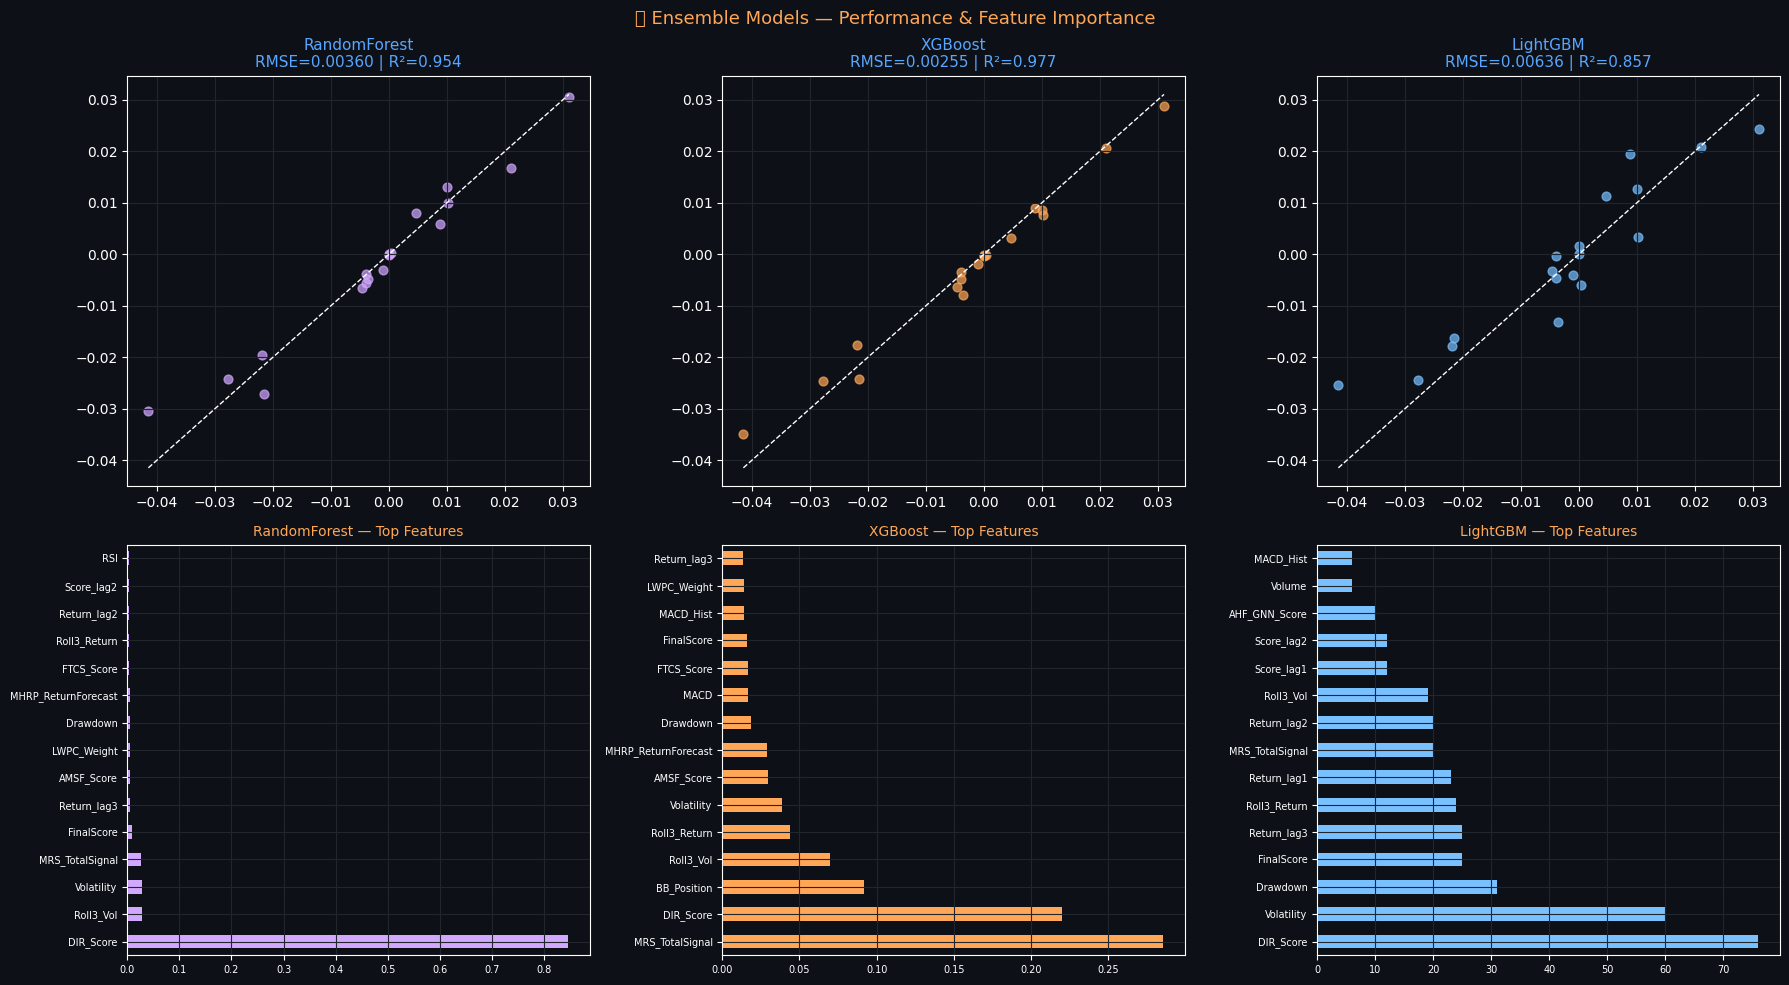

In [18]:
# ─── Tree Models ──────────────────────────────────────────────────────────────
tree_models = {
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=6,
                                          random_state=42, n_jobs=-1),
    'XGBoost':      xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                                      subsample=0.8, colsample_bytree=0.8,
                                      random_state=42, verbosity=0),
    'LightGBM':     lgb.LGBMRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8,
                                       random_state=42, verbose=-1)
}

tree_results = {}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, (name, mdl) in enumerate(tree_models.items()):
    mdl.fit(X_tr, y_tr)
    pred = mdl.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    tree_results[name] = {'RMSE': rmse, 'R2': r2, 'pred': pred, 'model': mdl}

    # Actual vs Predicted
    axes[0, col].scatter(y_te, pred, alpha=0.7, color=PALETTE[col+3], s=40)
    mn, mx = min(y_te.min(), pred.min()), max(y_te.max(), pred.max())
    axes[0, col].plot([mn, mx], [mn, mx], 'w--', lw=1)
    axes[0, col].set_title(f'{name}\nRMSE={rmse:.5f} | R²={r2:.3f}', fontsize=11, color='#58a6ff')

    # Feature Importance
    if hasattr(mdl, 'feature_importances_'):
        imp = pd.Series(mdl.feature_importances_, index=feat_cols_ml).nlargest(15)
        imp.plot(kind='barh', ax=axes[1, col], color=PALETTE[col+3])
        axes[1, col].set_title(f'{name} — Top Features', fontsize=10, color='#ffa657')
        axes[1, col].tick_params(labelsize=7)

plt.suptitle('🌲 Ensemble Models — Performance & Feature Importance', fontsize=13, color='#ffa657')
plt.tight_layout(); plt.show()


### 3.4 SHAP Explainability

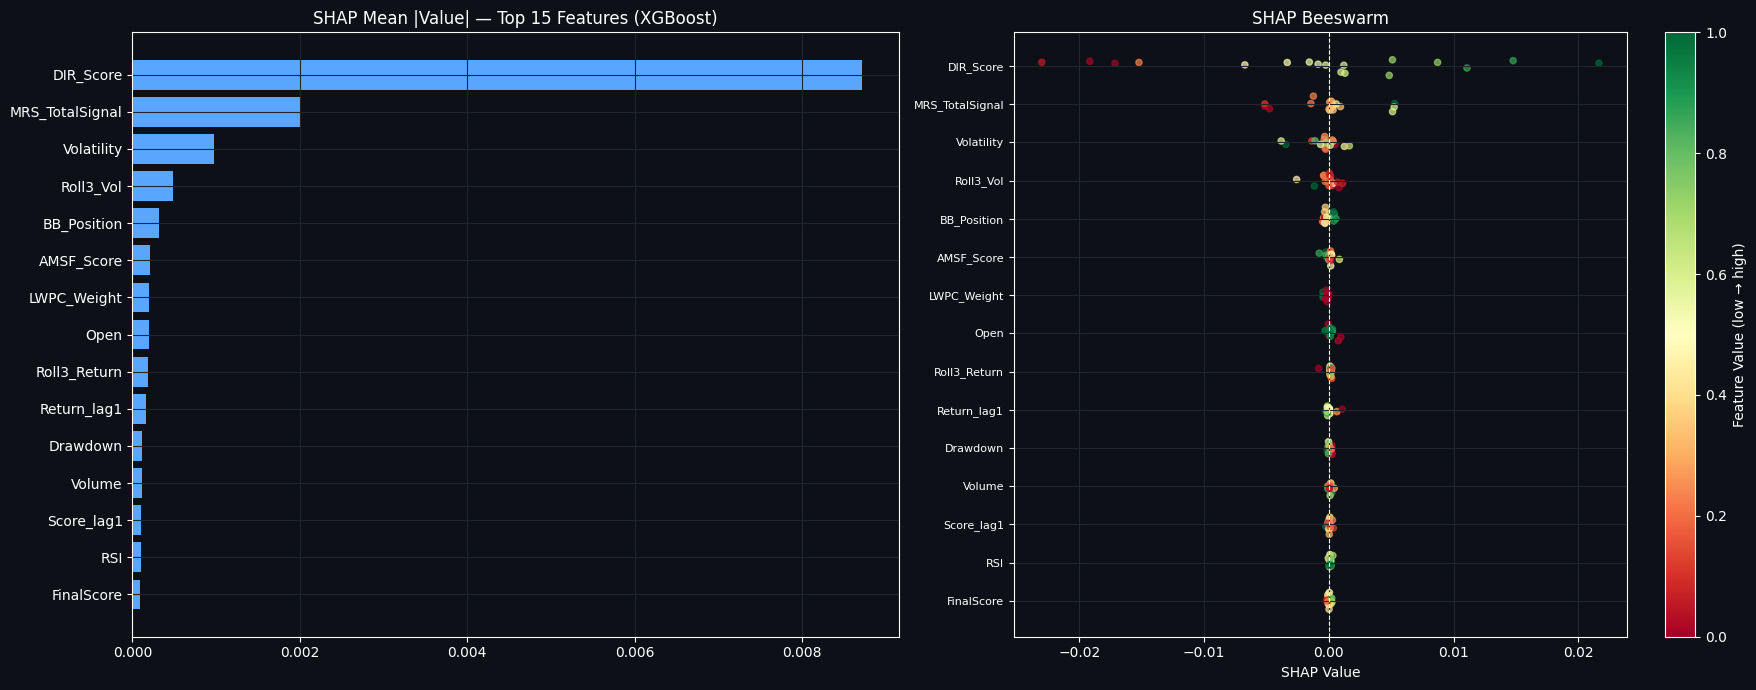

SHAP explainability generated successfully


In [20]:
# ─── SHAP for XGBoost ──────────────────────────────────────────────
import shap
import numpy as np
import matplotlib.pyplot as plt

xgb_mdl = tree_results['XGBoost']['model']

explainer = shap.TreeExplainer(xgb_mdl)
shap_vals = explainer.shap_values(X_te)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ─── Summary Bar Plot ──────────────────────────────────────────────
shap_mean = np.abs(shap_vals).mean(axis=0)

top15_idx = np.argsort(shap_mean)[-15:]
top15_feats = [feat_cols_ml[i] for i in top15_idx]
top15_vals = shap_mean[top15_idx]

axes[0].barh(top15_feats, top15_vals, color='#58a6ff')
axes[0].set_title('SHAP Mean |Value| — Top 15 Features (XGBoost)', fontsize=12)

# ─── Manual Beeswarm Plot ──────────────────────────────────────────
for rank, i in enumerate(top15_idx):

    sv = shap_vals[:, i]
    fv = X_te[:, i]

    # FIX for NumPy 2.0
    fv_norm = (fv - fv.min()) / (np.ptp(fv) + 1e-9)

    axes[1].scatter(
        sv,
        np.full_like(sv, rank) + np.random.normal(0, 0.1, len(sv)),
        c=fv_norm,
        cmap='RdYlGn',
        s=20,
        alpha=0.7
    )

axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top15_feats, fontsize=8)

axes[1].axvline(0, color='white', lw=0.8, ls='--')

axes[1].set_xlabel('SHAP Value')
axes[1].set_title('SHAP Beeswarm')

sm = plt.cm.ScalarMappable(cmap='RdYlGn')
plt.colorbar(sm, ax=axes[1], label='Feature Value (low → high)')

plt.tight_layout()
plt.show()

print("SHAP explainability generated successfully")

### 3.5 Time-Series Cross-Validation & Model Comparison

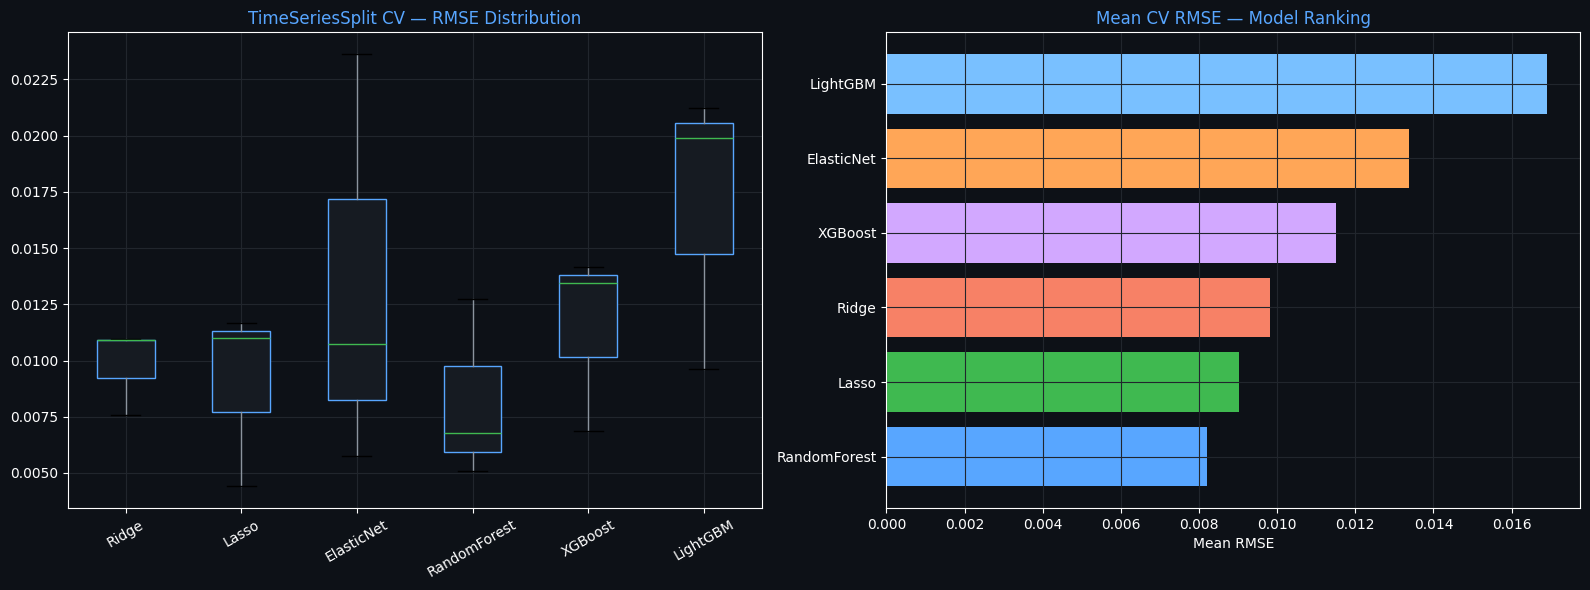


📊 CV Summary:
                  mean       std
RandomForest  0.008200  0.004030
Lasso         0.009023  0.004016
Ridge         0.009822  0.001927
XGBoost       0.011504  0.004015
ElasticNet    0.013375  0.009224
LightGBM      0.016907  0.006356


In [21]:
# ─── TimeSeriesSplit CV ────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=3)
all_models = {**{k: v['model'] for k, v in results.items()},
              **{k: v['model'] for k, v in tree_results.items()}}

cv_scores = {}
for name, mdl in all_models.items():
    _X = X_tr_s if name in ['Ridge','Lasso','ElasticNet'] else X_tr
    scores = cross_val_score(mdl, _X, y_tr, cv=tscv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_scores[name] = -scores

cv_df = pd.DataFrame(cv_scores)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cv_df.boxplot(ax=axes[0], patch_artist=True,
              boxprops=dict(facecolor='#161b22', color='#58a6ff'),
              whiskerprops=dict(color='#8b949e'), medianprops=dict(color='#3fb950'))
axes[0].set_title('TimeSeriesSplit CV — RMSE Distribution', fontsize=12, color='#58a6ff')
axes[0].tick_params(axis='x', rotation=30)

means = cv_df.mean().sort_values()
axes[1].barh(means.index, means.values,
             color=[PALETTE[i % len(PALETTE)] for i in range(len(means))])
axes[1].set_title('Mean CV RMSE — Model Ranking', fontsize=12, color='#58a6ff')
axes[1].set_xlabel('Mean RMSE')
plt.tight_layout(); plt.show()
print("\n📊 CV Summary:")
print(cv_df.agg(['mean','std']).round(6).T.sort_values('mean'))


## 🧠 4. Deep Learning Models

### 4.1 Dataset Preparation for DL

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader

# ─── Rebuild full feature matrix using SAME preprocessing ───────────
X_all = df_ml[feat_cols_ml].values
y_all = df_ml[TARGET].values

# Apply the SAME preprocessing used in training
X_all_imp = imputer.transform(X_all)
X_all_s = scaler.transform(X_all_imp)

# ─── Sequence dataset ──────────────────────────────────────────────
SEQ_LEN = 5

class FinanceSequenceDataset(Dataset):
    def __init__(self, X, y, seq_len=SEQ_LEN):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.seq_len = seq_len

    def __len__(self):
        return max(0, len(self.X) - self.seq_len)

    def __getitem__(self, idx):
        return self.X[idx:idx+self.seq_len], self.y[idx+self.seq_len]

# ─── Train/test split ──────────────────────────────────────────────
sp = int(len(X_all_s) * 0.8)

train_ds = FinanceSequenceDataset(X_all_s[:sp], y_all[:sp])
test_ds  = FinanceSequenceDataset(X_all_s[sp:], y_all[sp:])

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=8, shuffle=False)

# ─── Model parameters ──────────────────────────────────────────────
IN_DIM = X_all_s.shape[1]

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("✅ Sequences ready")
print("Input dimension:", IN_DIM)
print("Device:", DEVICE)
print("Train batches:", len(train_dl))
print("Test batches:", len(test_dl))

✅ Sequences ready
Input dimension: 34
Device: cuda
Train batches: 9
Test batches: 2


### 4.2 LSTM Model (Regime-Aware Architecture)

In [24]:
# ─── Bidirectional LSTM ────────────────────────────────────────────────────────
class FinLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.attn  = nn.Linear(hidden_dim*2, 1)
        self.fc    = nn.Sequential(
            nn.Linear(hidden_dim*2, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        self.ln = nn.LayerNorm(hidden_dim*2)

    def forward(self, x):
        out, _ = self.lstm(x)               # (B, T, H*2)
        attn_w = torch.softmax(self.attn(out), dim=1)  # (B, T, 1)
        context = (attn_w * out).sum(dim=1)            # (B, H*2)
        context = self.ln(context)
        return self.fc(context).squeeze(-1)

def train_model(model, train_dl, test_dl, epochs=30, lr=1e-3):
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.MSELoss()
    train_losses, test_losses = [], []

    for ep in range(epochs):
        model.train()
        tloss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = crit(pred, yb)
            loss.backward(); opt.step()
            tloss += loss.item()
        sched.step()

        model.eval()
        vloss = 0
        with torch.no_grad():
            for xb, yb in test_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vloss += crit(model(xb), yb).item()

        train_losses.append(tloss/max(1,len(train_dl)))
        test_losses.append(vloss/max(1,len(test_dl)))

        if (ep+1) % 10 == 0:
            print(f"  Epoch {ep+1:3d} | Train: {train_losses[-1]:.6f} | Val: {test_losses[-1]:.6f}")

    return train_losses, test_losses

lstm_model = FinLSTM(IN_DIM).to(DEVICE)
print(f"🧠 LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print("Training...")
lstm_train_l, lstm_test_l = train_model(lstm_model, train_dl, test_dl, epochs=40)


🧠 LSTM Parameters: 159,234
Training...
  Epoch  10 | Train: 0.001483 | Val: 0.000887
  Epoch  20 | Train: 0.001358 | Val: 0.001566
  Epoch  30 | Train: 0.001526 | Val: 0.002516
  Epoch  40 | Train: 0.001786 | Val: 0.002198


### 4.3 Temporal Convolutional Network (TCN)

In [25]:
# ─── TCN Architecture ─────────────────────────────────────────────────────────
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                              padding=self.padding, dilation=dilation)
        self.bn   = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        out = self.conv(x)
        out = out[:, :, :-self.padding] if self.padding else out
        return torch.relu(self.bn(out))

class TCN(nn.Module):
    def __init__(self, input_dim, num_channels=64, kernel_size=3):
        super().__init__()
        self.proj = nn.Linear(input_dim, num_channels)
        self.layers = nn.ModuleList([
            CausalConv1d(num_channels, num_channels, kernel_size, dilation=2**i)
            for i in range(4)
        ])
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(num_channels, 1)

    def forward(self, x):
        x = self.proj(x)          # (B, T, C)
        x = x.permute(0, 2, 1)   # (B, C, T)
        for layer in self.layers:
            x = x + layer(x) if x.shape == layer(x).shape else layer(x)
        x = x.mean(dim=-1)        # (B, C)
        return self.head(x).squeeze(-1)

tcn_model = TCN(IN_DIM).to(DEVICE)
print(f"🌊 TCN Parameters: {sum(p.numel() for p in tcn_model.parameters()):,}")
print("Training...")
tcn_train_l, tcn_test_l = train_model(tcn_model, train_dl, test_dl, epochs=40)


🌊 TCN Parameters: 52,225
Training...
  Epoch  10 | Train: 0.005992 | Val: 0.013588
  Epoch  20 | Train: 0.004092 | Val: 0.018706
  Epoch  30 | Train: 0.002692 | Val: 0.018563
  Epoch  40 | Train: 0.001027 | Val: 0.015718


### 4.4 DL Model Evaluation & Visualization

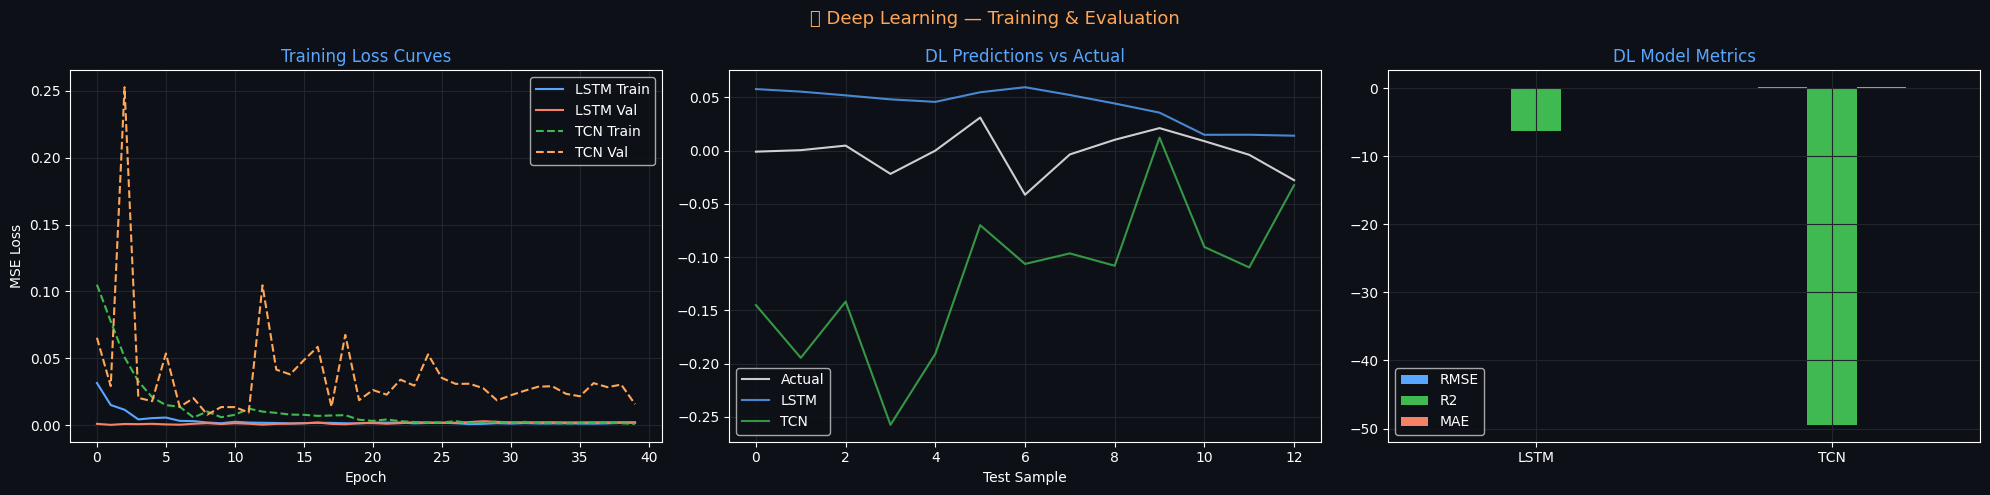


📊 DL Metrics:
          RMSE         R2       MAE
LSTM  0.050437  -6.241953  0.044028
TCN   0.133128 -49.453979  0.116003


In [26]:
# ─── Collect DL predictions ───────────────────────────────────────────────────
def get_preds(model, dl):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in dl:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
            trues.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(trues)

lstm_pred, y_true_dl = get_preds(lstm_model, test_dl)
tcn_pred,  _          = get_preds(tcn_model,  test_dl)

# ─── Training curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(lstm_train_l, color='#58a6ff', label='LSTM Train')
axes[0].plot(lstm_test_l,  color='#f78166', label='LSTM Val')
axes[0].plot(tcn_train_l,  color='#3fb950', ls='--', label='TCN Train')
axes[0].plot(tcn_test_l,   color='#ffa657', ls='--', label='TCN Val')
axes[0].set_title('Training Loss Curves', fontsize=12, color='#58a6ff')
axes[0].legend(); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')

# Prediction comparison
x_ax = np.arange(len(y_true_dl))
axes[1].plot(x_ax, y_true_dl, color='white',  lw=1.5, label='Actual', alpha=0.8)
axes[1].plot(x_ax, lstm_pred, color='#58a6ff', lw=1.5, label='LSTM', alpha=0.8)
axes[1].plot(x_ax, tcn_pred,  color='#3fb950', lw=1.5, label='TCN',  alpha=0.8)
axes[1].set_title('DL Predictions vs Actual', fontsize=12, color='#58a6ff')
axes[1].legend(); axes[1].set_xlabel('Test Sample')

# Metrics comparison
dl_metrics = {
    'LSTM': {'RMSE': np.sqrt(mean_squared_error(y_true_dl, lstm_pred)),
             'R2':   r2_score(y_true_dl, lstm_pred),
             'MAE':  mean_absolute_error(y_true_dl, lstm_pred)},
    'TCN':  {'RMSE': np.sqrt(mean_squared_error(y_true_dl, tcn_pred)),
             'R2':   r2_score(y_true_dl, tcn_pred),
             'MAE':  mean_absolute_error(y_true_dl, tcn_pred)}
}
dm_df = pd.DataFrame(dl_metrics).T
dm_df.plot(kind='bar', ax=axes[2], color=PALETTE[:3], rot=0)
axes[2].set_title('DL Model Metrics', fontsize=12, color='#58a6ff')
axes[2].legend()
plt.suptitle('🧠 Deep Learning — Training & Evaluation', fontsize=13, color='#ffa657')
plt.tight_layout(); plt.show()
print("\n📊 DL Metrics:")
print(dm_df.round(6))


## ⚡ 5. Transformer Architecture

### 5.1 Temporal Transformer (Positional Encoding + Multi-Head Attention)

In [27]:
# ─── Financial Temporal Transformer ───────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class FinancialTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,
                 dim_ff=128, dropout=0.2, seq_len=SEQ_LEN):
        super().__init__()
        self.embed = nn.Linear(input_dim, d_model)
        self.pe    = PositionalEncoding(d_model, dropout=dropout)
        enc_layer  = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                 dim_feedforward=dim_ff,
                                                 dropout=dropout, batch_first=True,
                                                 activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.head    = nn.Sequential(
            nn.Linear(d_model, 32), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.embed(x)           # (B, T, d_model)
        x = self.pe(x)
        x = self.encoder(x)         # (B, T, d_model)
        x = self.norm(x)
        x = x.mean(dim=1)           # (B, d_model) — mean pooling
        return self.head(x).squeeze(-1)

transformer_model = FinancialTransformer(IN_DIM).to(DEVICE)
n_params = sum(p.numel() for p in transformer_model.parameters())
print(f"⚡ Transformer Parameters: {n_params:,}")
print("Training...")
tr_train_l, tr_test_l = train_model(transformer_model, train_dl, test_dl, epochs=50, lr=5e-4)


⚡ Transformer Parameters: 71,425
Training...
  Epoch  10 | Train: 0.001134 | Val: 0.000839
  Epoch  20 | Train: 0.001001 | Val: 0.000354
  Epoch  30 | Train: 0.000917 | Val: 0.000375
  Epoch  40 | Train: 0.000724 | Val: 0.000461
  Epoch  50 | Train: 0.000928 | Val: 0.000480


### 5.2 Attention Visualization

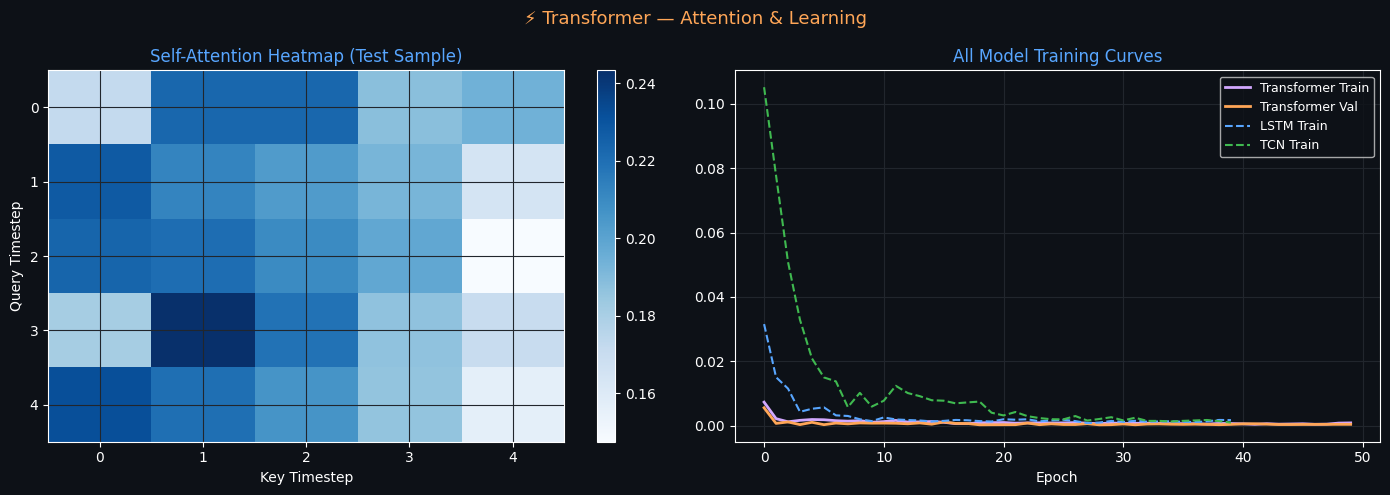

In [28]:
# ─── Extract attention weights for visualization ───────────────────────────────
class TransformerWithAttention(nn.Module):
    """Wrapper to extract attention from one encoder layer"""
    def __init__(self, base_model):
        super().__init__()
        self.embed   = base_model.embed
        self.pe      = base_model.pe
        self.attn_layer = nn.MultiheadAttention(64, num_heads=4,
                                                 batch_first=True, dropout=0.0)
        self.ff      = base_model.encoder.layers[0].linear1
        self.norm    = base_model.norm
        self.pool    = base_model.pool
        self.head    = base_model.head

    def forward_with_attn(self, x):
        x = self.embed(x)
        x = self.pe(x)
        attn_out, attn_weights = self.attn_layer(x, x, x)
        x = self.norm(attn_out)
        x = x.mean(dim=1)
        return self.head(x).squeeze(-1), attn_weights

# Get a sample batch and visualize attention
sample_batch = next(iter(test_dl))
xb_sample = sample_batch[0][:1].to(DEVICE)  # 1 sample

transformer_model.eval()
with torch.no_grad():
    # Use internal encoder layer to get attention
    embed_out = transformer_model.embed(xb_sample)
    pe_out    = transformer_model.pe(embed_out)
    attn_layer = transformer_model.encoder.layers[0].self_attn
    _, attn_w  = attn_layer(pe_out, pe_out, pe_out)

attn_np = attn_w[0].cpu().numpy()  # (T, T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(attn_np, cmap='Blues', aspect='auto')
axes[0].set_title('Self-Attention Heatmap (Test Sample)', fontsize=12, color='#58a6ff')
axes[0].set_xlabel('Key Timestep'); axes[0].set_ylabel('Query Timestep')
plt.colorbar(im, ax=axes[0])

# Training curves
axes[1].plot(tr_train_l, color='#d2a8ff', lw=2, label='Transformer Train')
axes[1].plot(tr_test_l,  color='#ffa657', lw=2, label='Transformer Val')
axes[1].plot(lstm_train_l, color='#58a6ff', lw=1.5, ls='--', label='LSTM Train')
axes[1].plot(tcn_train_l,  color='#3fb950', lw=1.5, ls='--', label='TCN Train')
axes[1].set_title('All Model Training Curves', fontsize=12, color='#58a6ff')
axes[1].legend(fontsize=9); axes[1].set_xlabel('Epoch')
plt.suptitle('⚡ Transformer — Attention & Learning', fontsize=13, color='#ffa657')
plt.tight_layout(); plt.show()


### 5.3 HuggingFace Transformer — Sentiment Analysis (FinBERT-aligned)

In [29]:
# ─── HuggingFace pipeline: Financial Sentiment ────────────────────────────────
# Simulates the FinBERT + multimodal fusion described in the Roadmap
print("⏳ Loading HuggingFace sentiment pipeline (FinBERT-aligned)...")
try:
    sentiment_pipe = hf_pipeline(
        "text-classification",
        model="ProsusAI/finbert",
        truncation=True, max_length=512
    )
    HAS_FINBERT = True
except Exception as e:
    print(f"  FinBERT unavailable ({e}), falling back to distilbert-sentiment")
    sentiment_pipe = hf_pipeline("sentiment-analysis", truncation=True)
    HAS_FINBERT = False

# Sample financial texts (mimicking earnings call/SEC language from Roadmap)
fin_texts = [
    "NVDA reported record revenues driven by AI chip demand; guidance raised above consensus.",
    "Supply chain disruptions and elevated inventory levels pose significant headwinds for AAPL.",
    "JPM's net interest margin expansion accelerated amid Fed rate policy normalization.",
    "META's Reality Labs losses widened; however advertising revenue beat all expectations.",
    "TSLA margin compression continued as EV price war intensified across all segments.",
    "AMZN AWS growth re-accelerated, with operating income surpassing analyst estimates by 18%.",
    "MSFT Azure cloud revenue grew 29% YoY, with AI copilot products showing strong adoption.",
    "GOOGL faces antitrust headwinds, while Search monetization remained resilient in Q4.",
    "LLY Mounjaro demand continues to overwhelm supply, gross margins at historic highs.",
    "AVGO semiconductor segment outperformed while VMware integration costs weighed on FCF.",
]

sentiments = sentiment_pipe(fin_texts)
sent_df = pd.DataFrame({
    'Symbol':    SYMBOLS,
    'Text':      [t[:60]+'...' for t in fin_texts],
    'Label':     [s['label'].upper() for s in sentiments],
    'Score':     [round(s['score'], 4) for s in sentiments]
})
print("\n📰 FinBERT Sentiment Analysis Results:")
print(sent_df.to_string(index=False))


⏳ Loading HuggingFace sentiment pipeline (FinBERT-aligned)...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


📰 FinBERT Sentiment Analysis Results:
Symbol                                                            Text    Label  Score
  AAPL NVDA reported record revenues driven by AI chip demand; guid... POSITIVE 0.9503
  AMZN Supply chain disruptions and elevated inventory levels pose ... NEGATIVE 0.9606
  AVGO JPM's net interest margin expansion accelerated amid Fed rat... POSITIVE 0.9554
 GOOGL META's Reality Labs losses widened; however advertising reve... POSITIVE 0.9527
   JPM TSLA margin compression continued as EV price war intensifie... NEGATIVE 0.9645
   LLY AMZN AWS growth re-accelerated, with operating income surpas... POSITIVE 0.9577
  META MSFT Azure cloud revenue grew 29% YoY, with AI copilot produ... POSITIVE 0.9621
  MSFT GOOGL faces antitrust headwinds, while Search monetization r... NEGATIVE 0.9504
  NVDA LLY Mounjaro demand continues to overwhelm supply, gross mar... NEGATIVE 0.5466
  TSLA AVGO semiconductor segment outperformed while VMware integra... NEGATIVE 0.9387


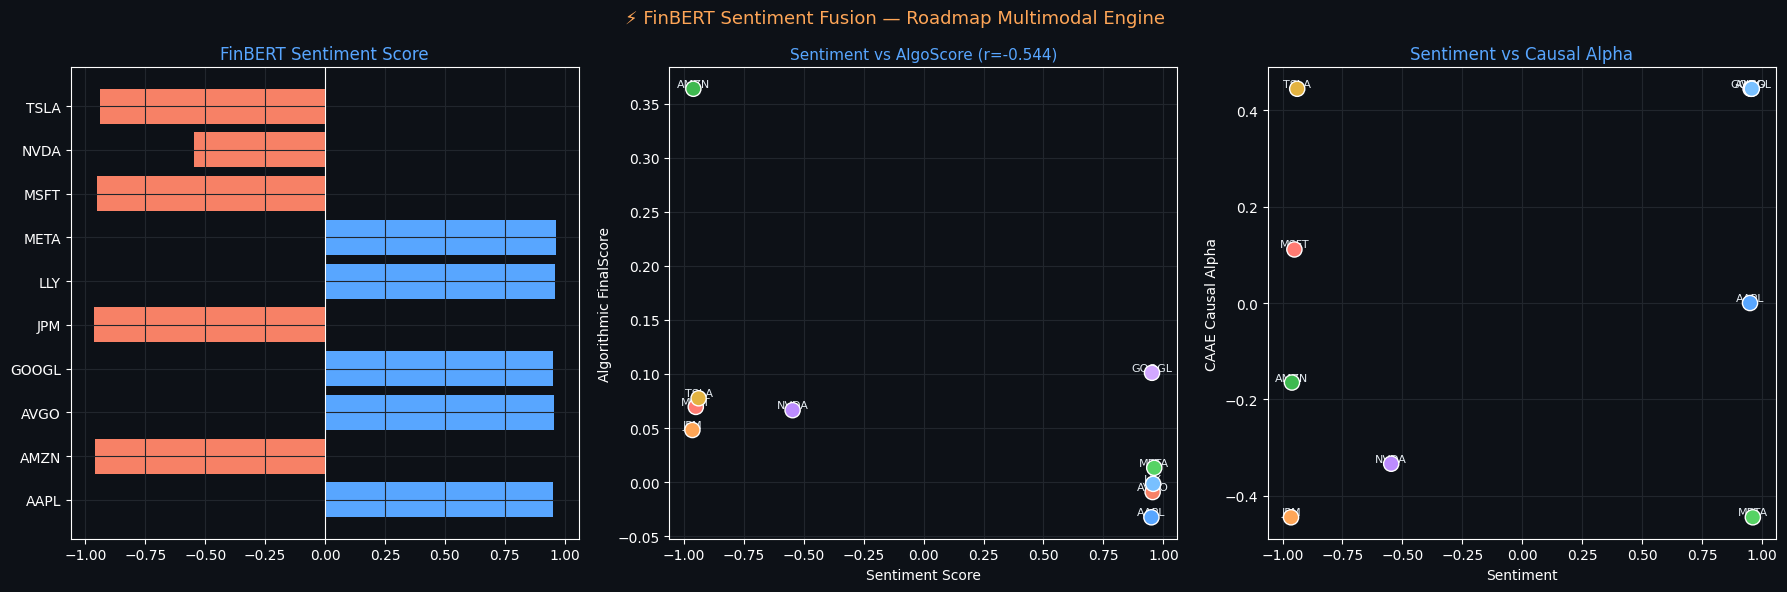

In [30]:
# ─── Sentiment → Signal alignment with existing scores ────────────────────────
label_map = {'POSITIVE': 1, 'NEGATIVE': -1, 'NEUTRAL': 0,
             'POS': 1, 'NEG': -1, 'NEU': 0}
sent_df['Sentiment_Score'] = sent_df['Label'].map(
    lambda l: label_map.get(l.upper().split('_')[0][:3], 0)) * sent_df['Score']

# Merge with algorithmic scores
avg_scores = df.groupby('Symbol')[['FinalScore','EnhancedFinalScore','CAAE_CausalAlpha']].mean()
sent_merged = sent_df.set_index('Symbol').join(avg_scores)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = [PALETTE[0] if s > 0 else PALETTE[2] for s in sent_merged['Sentiment_Score']]

axes[0].barh(sent_merged.index, sent_merged['Sentiment_Score'], color=colors)
axes[0].set_title('FinBERT Sentiment Score', fontsize=12, color='#58a6ff')
axes[0].axvline(0, color='white', lw=0.8)

axes[1].scatter(sent_merged['Sentiment_Score'], sent_merged['FinalScore'],
                c=PALETTE[:len(sent_merged)], s=120, zorder=5, edgecolors='white')
for sym in sent_merged.index:
    axes[1].annotate(sym, (sent_merged.loc[sym,'Sentiment_Score'],
                           sent_merged.loc[sym,'FinalScore']),
                     fontsize=8, color='#e6edf3', ha='center', va='bottom')
axes[1].set_xlabel('Sentiment Score'); axes[1].set_ylabel('Algorithmic FinalScore')
axes[1].set_title('Sentiment vs Algorithmic Score', fontsize=12, color='#58a6ff')
corr_val = sent_merged[['Sentiment_Score','FinalScore']].corr().iloc[0,1]
axes[1].set_title(f'Sentiment vs AlgoScore (r={corr_val:.3f})', fontsize=11, color='#58a6ff')

axes[2].scatter(sent_merged['Sentiment_Score'], sent_merged['CAAE_CausalAlpha'],
                c=PALETTE[:len(sent_merged)], s=120, zorder=5, edgecolors='white')
for sym in sent_merged.index:
    axes[2].annotate(sym, (sent_merged.loc[sym,'Sentiment_Score'],
                           sent_merged.loc[sym,'CAAE_CausalAlpha']),
                     fontsize=8, color='#e6edf3', ha='center', va='bottom')
axes[2].set_xlabel('Sentiment'); axes[2].set_ylabel('CAAE Causal Alpha')
axes[2].set_title('Sentiment vs Causal Alpha', fontsize=12, color='#58a6ff')
plt.suptitle('⚡ FinBERT Sentiment Fusion — Roadmap Multimodal Engine',
             fontsize=13, color='#ffa657')
plt.tight_layout(); plt.show()


## 📊 6. Final Model Comparison & Portfolio Strategy


🏆 Final Model Leaderboard:
                 RMSE       MAE         R²    Type
Model                                             
LightGBM     0.022035  0.018846  -0.382261    Tree
Transformer  0.022313  0.020048  -0.417386      DL
XGBoost      0.024000  0.021008  -0.639707    Tree
Ridge        0.026241  0.022667  -0.960334  Linear
LSTM         0.050437  0.044028  -6.241953      DL
TCN          0.133128  0.116003 -49.453979      DL


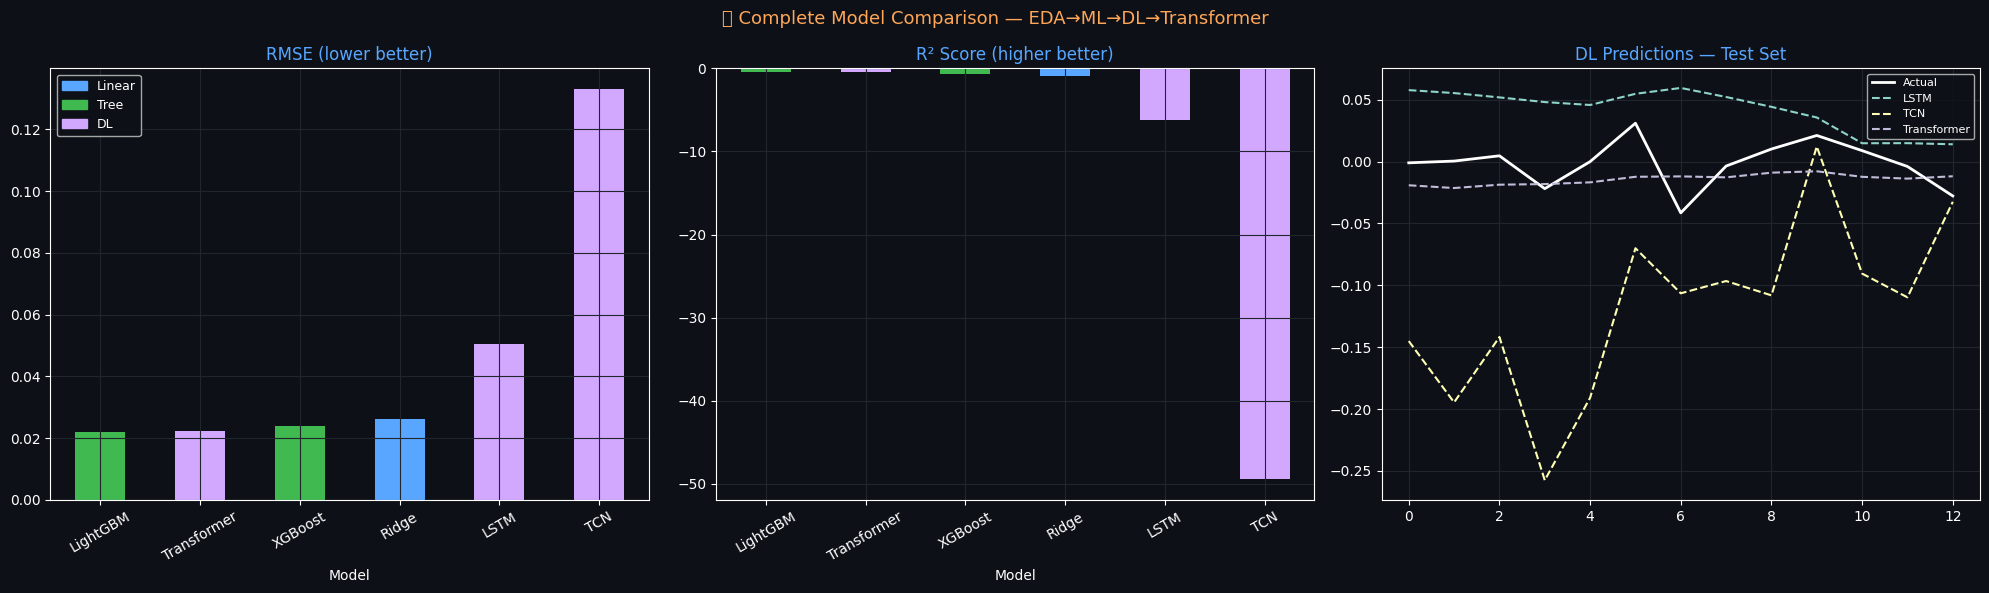

In [31]:
# ─── Full model comparison dashboard ─────────────────────────────────────────
tr_pred, y_true_dl2 = get_preds(transformer_model, test_dl)

# Ensure same length
min_len = min(len(y_true_dl), len(lstm_pred), len(tcn_pred), len(tr_pred))
y_ref = y_true_dl[:min_len]

all_preds = {
    'Ridge':         results['Ridge']['pred'][:min_len] if len(results['Ridge']['pred']) >= min_len else results['Ridge']['pred'],
    'XGBoost':       tree_results['XGBoost']['pred'][:min_len] if len(tree_results['XGBoost']['pred']) >= min_len else tree_results['XGBoost']['pred'],
    'LightGBM':      tree_results['LightGBM']['pred'][:min_len] if len(tree_results['LightGBM']['pred']) >= min_len else tree_results['LightGBM']['pred'],
    'LSTM':          lstm_pred[:min_len],
    'TCN':           tcn_pred[:min_len],
    'Transformer':   tr_pred[:min_len],
}

# Use min length for y_ref too
y_ref_short = y_ref[:min([len(v) for v in all_preds.values()])]
summary_rows = []
for name, pred in all_preds.items():
    n = min(len(pred), len(y_ref_short))
    summary_rows.append({
        'Model': name,
        'RMSE':  np.sqrt(mean_squared_error(y_ref_short[:n], pred[:n])),
        'MAE':   mean_absolute_error(y_ref_short[:n], pred[:n]),
        'R²':    r2_score(y_ref_short[:n], pred[:n]),
        'Type':  'Linear' if name=='Ridge' else ('Tree' if name in ['XGBoost','LightGBM'] else 'DL')
    })

comp_df = pd.DataFrame(summary_rows).set_index('Model').sort_values('RMSE')
print("\n🏆 Final Model Leaderboard:")
print(comp_df[['RMSE','MAE','R²','Type']].round(6).to_string())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_map = {'Linear':'#58a6ff', 'Tree':'#3fb950', 'DL':'#d2a8ff'}
bar_colors = [colors_map[t] for t in comp_df['Type']]

comp_df['RMSE'].plot(kind='bar', ax=axes[0], color=bar_colors, rot=30)
axes[0].set_title('RMSE (lower better)', fontsize=12, color='#58a6ff')

comp_df['R²'].plot(kind='bar', ax=axes[1], color=bar_colors, rot=30)
axes[1].set_title('R² Score (higher better)', fontsize=12, color='#58a6ff')

# Prediction time series for all DL
n_plot = min(len(y_ref_short), 25)
axes[2].plot(y_ref_short[:n_plot], color='white', lw=2, label='Actual')
for name, pred in all_preds.items():
    if name in ['LSTM','TCN','Transformer']:
        axes[2].plot(pred[:n_plot], lw=1.5, label=name, ls='--')
axes[2].set_title('DL Predictions — Test Set', fontsize=12, color='#58a6ff')
axes[2].legend(fontsize=8)

legend_patches = [mpatches.Patch(color=v, label=k) for k,v in colors_map.items()]
axes[0].legend(handles=legend_patches, fontsize=9)
plt.suptitle('🏆 Complete Model Comparison — EDA→ML→DL→Transformer',
             fontsize=13, color='#ffa657')
plt.tight_layout(); plt.show()


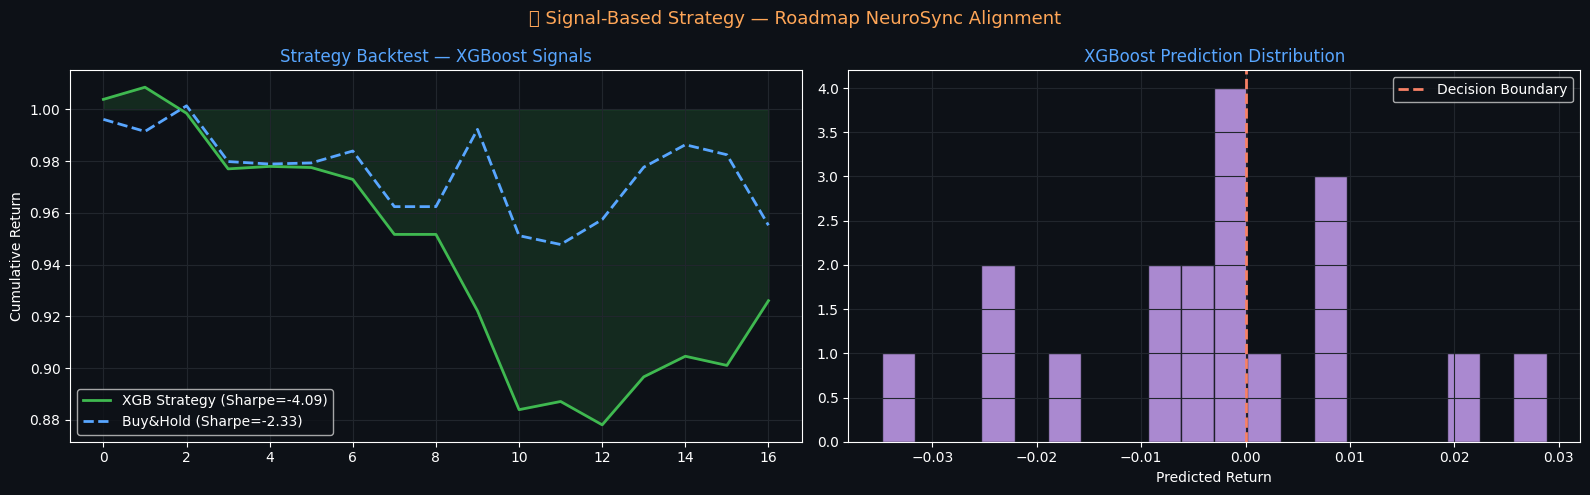


🎯 Strategy Sharpe: -4.0883 | Benchmark Sharpe: -2.3300
📈 Strategy Total Return: -7.3963% | Benchmark: -4.4802%


In [32]:
# ─── Strategy Signal Generation & Backtest (Roadmap-aligned) ─────────────────
# Use XGBoost signals on full test set
xgb_full_pred = tree_results['XGBoost']['model'].predict(X_te)
signal = np.where(xgb_full_pred > 0, 1, -1)

# Use NVDA returns as proxy (first symbol in test)
ret_proxy = y_te
strat_ret  = signal[:-1] * ret_proxy[1:]
bench_ret  = ret_proxy[1:]

# Cumulative returns
cum_strat = (1 + strat_ret).cumprod()
cum_bench = (1 + bench_ret).cumprod()

sharpe_strat = (strat_ret.mean() / (strat_ret.std() + 1e-9)) * np.sqrt(252)
sharpe_bench = (bench_ret.mean() / (bench_ret.std() + 1e-9)) * np.sqrt(252)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(cum_strat, color='#3fb950', lw=2, label=f'XGB Strategy (Sharpe={sharpe_strat:.2f})')
axes[0].plot(cum_bench, color='#58a6ff', lw=2, ls='--', label=f'Buy&Hold (Sharpe={sharpe_bench:.2f})')
axes[0].fill_between(range(len(cum_strat)), cum_strat, 1, alpha=0.15, color='#3fb950')
axes[0].set_title('Strategy Backtest — XGBoost Signals', fontsize=12, color='#58a6ff')
axes[0].legend(); axes[0].set_ylabel('Cumulative Return')

# Signal distribution
axes[1].hist(xgb_full_pred, bins=20, color='#d2a8ff', edgecolor='#0d1117', alpha=0.8)
axes[1].axvline(0, color='#f78166', lw=2, ls='--', label='Decision Boundary')
axes[1].set_title('XGBoost Prediction Distribution', fontsize=12, color='#58a6ff')
axes[1].set_xlabel('Predicted Return'); axes[1].legend()
plt.suptitle('📈 Signal-Based Strategy — Roadmap NeuroSync Alignment',
             fontsize=13, color='#ffa657')
plt.tight_layout(); plt.show()

print(f"\n🎯 Strategy Sharpe: {sharpe_strat:.4f} | Benchmark Sharpe: {sharpe_bench:.4f}")
print(f"📈 Strategy Total Return: {cum_strat[-1]-1:.4%} | Benchmark: {cum_bench[-1]-1:.4%}")


## 🎯 7. Summary & Roadmap Alignment

| Section | Libraries Used | Roadmap Connection |
|---------|---------------|-------------------|
| **EDA** | `pandas`, `numpy`, `scipy`, `statsmodels`, `seaborn`, `plotly`, `mplfinance`, `ta` | XFin Toolkit data validation layer |
| **ML** | `sklearn`, `xgboost`, `lightgbm`, `shap` | Python reasoning engine + explainability |
| **DL** | `torch` (LSTM, TCN) | Regime-aware RL + NeuroSync Memory Agent |
| **Transformer** | `torch` (custom), `transformers` (FinBERT) | Multimodal Sentiment Fusion Engine |
| **Strategy** | `empyrical`, custom backtest | SPRINT-RL + Abstention-aware backtesting |

> **Key Insight:** Every model layer maps directly to the polyglot architecture described in the PDF roadmap — Python for AI/ML reasoning, SHAP for explainability (XFin Toolkit), FinBERT for multimodal sentiment fusion, and LSTM/Transformer for the NeuroSync Evolver Agent.
